# Final Test Evaluation: fixed Optuna configurations + baselines

Этот notebook выполняет **held-out test evaluation** после Stage 1 Optuna.

Протокол:

- тестируются все **8 optimized configurations**: 4 алгоритма × 2 набора признаков (`corr`, `hybrid`);
- **Optuna не запускается** и параметры не подбираются;
- для TS (`discounted_lints`, `sw_lints`) используется `30` fresh test seeds;
- для UCB (`discounted_linucb`, `sw_linucb`) используется `1` seed;
- дополнительно считаются baselines:
  - buy-and-hold with entry commission;
  - screening/default bandit parameters;
  - random policy `action ∈ {0,1}`;
  - EMA(21)/EMA(50) crossover;
  - RSI(14) mean-reversion with levels 30/70;
- считаются aggregate, seed-level и per-symbol метрики;
- строятся графики для comparison, robustness и diagnostics.

Основная test-метрика сохраняет логику HPO:

\[
median_{seed}(median_{symbol}(return\_pct))
\]

Для UCB это эквивалентно `median_symbol_return_pct`, так как seed один.

In [1]:
import json
import sys
import math
import gc
from pathlib import Path
from datetime import datetime
from typing import Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path(r"D:\PythonProjects\VKR")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_processing.functions.klines_dataloader import KlinesDataLoader
from data_processing.functions.stream_indicators import stream_TA_lib
from data_processing.functions.transform_indicators import transform_indicators_df
from data_processing.functions.rolling_z_score_clip import rolling_z_score_clip_df
from backtest.backtest_class import Backtesting

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\PythonProjects\VKR


## 1. Protocol config

Проверь пути к двум run-папкам Optuna.  
Если notebook запускается для реального final evaluation, оставь `SMOKE_TEST=False`.

In [2]:
# =====================================================================
# Project paths
# =====================================================================
FEATURE_SELECTION_ROOT = PROJECT_ROOT / "feature_selection" / "hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2"
OPTUNA_ROOT = FEATURE_SELECTION_ROOT / "stage1_optuna_constrained_median_with_ts_confirmation_local"
FEATURE_CACHE_DIR = FEATURE_SELECTION_ROOT / "stage1_optuna_feature_cache"

RUN_DIRS = {
    "A_discounted": OPTUNA_ROOT / "A_discounted_20260515_234647",
    "B_sliding": OPTUNA_ROOT / "B_sliding_20260516_002256",
}

FINAL_TEST_RUN_LABEL = f"final_test_fixed_optuna_30TS_1UCB_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = FEATURE_SELECTION_ROOT / "final_test_evaluation_outputs" / FINAL_TEST_RUN_LABEL
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"
PLOTS_DIR = OUTPUT_DIR / "plots"

for d in [OUTPUT_DIR, DIAGNOSTICS_DIR, PLOTS_DIR, FEATURE_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =====================================================================
# Trading / data protocol
# =====================================================================
ALL_SYMBOLS = ["BTCUSDT", "DOGEUSDT", "ETHUSDT", "SOLUSDT", "XRPUSDT"]
META_COLS = ["timestamp", "symbol", "open", "high", "low", "close", "volume"]
ACTIONS = [0, 1]
STATE_FEATURES = ["state_in_position", "state_log_bars_in_position", "state_unrealized_pnl"]

VAL_BARS = 2000
TEST_BARS = 2000
EMBARGO_BARS = 0
HORIZON = 10
TRADE_COST = 0.0025
ALPHA_OUT = 0.5

START_CAPITAL = 100.0
POSITION_SIZE = 0.10
MIN_HOLD_BARS = 4
COOLDOWN_BARS = 2
CONFIDENCE_THRESHOLD = 0.005
UPDATE_ON_TEST = True

REWARD_CLIP = 0.10

# =====================================================================
# Final test seeds
# =====================================================================
TEST_TS_SEEDS = list(range(9000, 9030))    # 30 seeds
TEST_UCB_SEEDS = [9000]                    # 1 seed by protocol
RANDOM_POLICY_SEEDS = list(range(9100, 9130))

SMOKE_TEST = False
if SMOKE_TEST:
    TEST_TS_SEEDS = TEST_TS_SEEDS[:2]
    RANDOM_POLICY_SEEDS = RANDOM_POLICY_SEEDS[:2]

# =====================================================================
# Default/screening bandit parameters
# =====================================================================
DEFAULT_DISCOUNT_FACTOR = 0.998
DEFAULT_WINDOW_SIZE = 500
DEFAULT_LAMBDA_PRIOR = 1.0
DEFAULT_NOISE_STD = 0.03
DEFAULT_UCB_ALPHA = 0.10

BANDIT_TYPE_MAP = {
    "discounted_lints": "discounted_lints",
    "discounted_linucb": "discounted_linucb",
    "sw_lints": "sw_lints",
    "sw_linucb": "sw_linucb",
}
TS_BANDITS = {"discounted_lints", "sw_lints"}
UCB_BANDITS = {"discounted_linucb", "sw_linucb"}

# =====================================================================
# Baseline toggles
# =====================================================================
RUN_OPTIMIZED_CONFIGS = True
RUN_DEFAULT_BANDIT_BASELINES = True
RUN_STATIC_BASELINES = True
RUN_RANDOM_BASELINE = True
RUN_RULE_BASELINES = True
APPLY_EXECUTION_CONSTRAINTS_TO_RULE_BASELINES = True

# Rule baselines use z24 OHLCV split; OHLCV is the same for test period across z-windows.
BASELINE_Z_WINDOW = 24

print("OUTPUT_DIR:", OUTPUT_DIR)
for k, p in RUN_DIRS.items():
    print(k, "exists=", p.exists(), "path=", p)

OUTPUT_DIR: D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\final_test_evaluation_outputs\final_test_fixed_optuna_30TS_1UCB_20260517_013520
A_discounted exists= True path= D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\stage1_optuna_constrained_median_with_ts_confirmation_local\A_discounted_20260515_234647
B_sliding exists= True path= D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\stage1_optuna_constrained_median_with_ts_confirmation_local\B_sliding_20260516_002256


## 2. Load fixed final configurations from A/B Optuna outputs

- TS rows use `ts_best_trial_per_algorithm_method_after_confirmation.csv` for final parameters.
- UCB rows use `best_trial_per_algorithm_method.csv`.
- Validation selected return is taken from `best_trial_per_algorithm_method_with_ts_confirmation.csv`.

In [3]:
def read_required_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)


def first_non_nan(row: pd.Series, candidates: list[str], default=None):
    for c in candidates:
        if c in row.index:
            val = row[c]
            if pd.notna(val):
                return val
    return default


def parse_features(s: Any) -> list[str]:
    if isinstance(s, list):
        return list(s)
    if pd.isna(s):
        return []
    return [x for x in str(s).split("|") if x]


def default_bandit_params(algorithm: str) -> dict:
    params = {
        "bandit_type": BANDIT_TYPE_MAP[algorithm],
        "lambda_prior": DEFAULT_LAMBDA_PRIOR,
        "reward_clip": REWARD_CLIP,
    }
    if algorithm.startswith("discounted"):
        params["discount_factor"] = DEFAULT_DISCOUNT_FACTOR
    else:
        params["window_size"] = DEFAULT_WINDOW_SIZE
    if algorithm in TS_BANDITS:
        params["noise_std"] = DEFAULT_NOISE_STD
    else:
        params["ucb_alpha"] = DEFAULT_UCB_ALPHA
    return params


def params_from_selected_row(row: pd.Series) -> dict:
    algorithm = str(row["bandit_name"])
    params = {
        "bandit_type": BANDIT_TYPE_MAP[algorithm],
        "lambda_prior": float(first_non_nan(row, ["param_lambda_prior", "best_param_lambda_prior"])),
        "reward_clip": float(first_non_nan(row, ["param_reward_clip", "best_param_reward_clip"], REWARD_CLIP)),
    }
    if algorithm.startswith("discounted"):
        params["discount_factor"] = float(first_non_nan(row, ["param_discount_factor", "best_param_discount_factor"]))
    else:
        params["window_size"] = int(first_non_nan(row, ["param_window_size", "best_param_window_size"]))
    if algorithm in TS_BANDITS:
        params["noise_std"] = float(first_non_nan(row, ["param_noise_std", "best_param_noise_std"]))
    else:
        params["ucb_alpha"] = float(first_non_nan(row, ["param_ucb_alpha", "best_param_ucb_alpha"]))
    return params


def load_final_configs_from_run(run_name: str, run_dir: Path) -> pd.DataFrame:
    selected = read_required_csv(run_dir / "best_trial_per_algorithm_method_with_ts_confirmation.csv")
    feature_pairs = read_required_csv(run_dir / "feature_pairs_to_optimize.csv")
    best_optuna = read_required_csv(run_dir / "best_trial_per_algorithm_method.csv")
    ts_confirm_path = run_dir / "ts_best_trial_per_algorithm_method_after_confirmation.csv"
    ts_confirm = pd.read_csv(ts_confirm_path) if ts_confirm_path.exists() else pd.DataFrame()

    rows = []
    for _, sel in selected.iterrows():
        algorithm = str(sel["bandit_name"])
        method_group = str(sel["method_group"])
        set_name = str(sel["set_name"])
        key_mask = (
            feature_pairs["algorithm"].astype(str).eq(algorithm)
            & feature_pairs["method_group"].astype(str).eq(method_group)
            & feature_pairs["set_name"].astype(str).eq(set_name)
        )
        if not key_mask.any():
            raise ValueError(f"No feature pair found for {algorithm}/{method_group}/{set_name} in {run_dir}")
        fp = feature_pairs[key_mask].iloc[0]

        if algorithm in TS_BANDITS:
            source_df = ts_confirm
            mask = (
                source_df["bandit_name"].astype(str).eq(algorithm)
                & source_df["method_group"].astype(str).eq(method_group)
                & source_df["set_name"].astype(str).eq(set_name)
            )
            if not mask.any():
                raise ValueError(f"No TS confirmation params found for {algorithm}/{method_group}/{set_name}")
            param_row = source_df[mask].iloc[0]
            selection_source = "ts_confirmation"
            selected_trial_number = int(param_row["original_trial_number"])
        else:
            source_df = best_optuna
            mask = (
                source_df["bandit_name"].astype(str).eq(algorithm)
                & source_df["method_group"].astype(str).eq(method_group)
                & source_df["set_name"].astype(str).eq(set_name)
            )
            if not mask.any():
                raise ValueError(f"No Optuna best params found for {algorithm}/{method_group}/{set_name}")
            param_row = source_df[mask].iloc[0]
            selection_source = "optuna_best_ucb"
            selected_trial_number = int(param_row["trial_number"])

        params = params_from_selected_row(param_row)
        validation_selected_return = float(sel["selected_median_of_seed_median_return_pct"])
        rows.append({
            "run_name": run_name,
            "config_type": "optimized",
            "algorithm": algorithm,
            "bandit_name": algorithm,
            "algorithm_family": "discounted" if algorithm.startswith("discounted") else "sliding_window",
            "exploration_family": "TS" if algorithm in TS_BANDITS else "UCB",
            "method_group": method_group,
            "set_name": set_name,
            "z_window": int(fp["z_window"]),
            "alpha_out": ALPHA_OUT,
            "features": parse_features(fp["features"]),
            "n_market_features": int(fp["n_features"]),
            "bandit_params": params,
            "bandit_params_json": json.dumps(params, ensure_ascii=False, sort_keys=True),
            "selected_trial_number": selected_trial_number,
            "selection_source": selection_source,
            "validation_selected_return_pct": validation_selected_return,
            "validation_selected_drawdown_abs": float(sel.get("selected_median_max_drawdown_abs", np.nan)),
            "validation_selected_profit_factor": float(sel.get("selected_median_profit_factor", np.nan)),
            "validation_selected_total_trades": float(sel.get("selected_median_total_trades", np.nan)),
        })
    return pd.DataFrame(rows)


optimized_configs = []
for run_name, run_dir in RUN_DIRS.items():
    optimized_configs.append(load_final_configs_from_run(run_name, run_dir))
OPTIMIZED_CONFIGS = pd.concat(optimized_configs, ignore_index=True)

# Default/screening versions for the same algorithm-feature pairs.
DEFAULT_CONFIGS = OPTIMIZED_CONFIGS.copy()
DEFAULT_CONFIGS["config_type"] = "screening_default"
DEFAULT_CONFIGS["selection_source"] = "screening_default_params"
DEFAULT_CONFIGS["selected_trial_number"] = 0
DEFAULT_CONFIGS["validation_selected_return_pct"] = np.nan
DEFAULT_CONFIGS["validation_selected_drawdown_abs"] = np.nan
DEFAULT_CONFIGS["validation_selected_profit_factor"] = np.nan
DEFAULT_CONFIGS["validation_selected_total_trades"] = np.nan
DEFAULT_CONFIGS["bandit_params"] = DEFAULT_CONFIGS["algorithm"].map(default_bandit_params)
DEFAULT_CONFIGS["bandit_params_json"] = DEFAULT_CONFIGS["bandit_params"].map(lambda d: json.dumps(d, ensure_ascii=False, sort_keys=True))

CONFIGS_TO_TEST = OPTIMIZED_CONFIGS.copy()
if RUN_DEFAULT_BANDIT_BASELINES:
    CONFIGS_TO_TEST = pd.concat([CONFIGS_TO_TEST, DEFAULT_CONFIGS], ignore_index=True)

CONFIGS_TO_TEST["config_id"] = (
    CONFIGS_TO_TEST["config_type"] + "__" +
    CONFIGS_TO_TEST["algorithm"] + "__" +
    CONFIGS_TO_TEST["method_group"] + "__" +
    CONFIGS_TO_TEST["set_name"]
)
CONFIGS_TO_TEST["features_pipe"] = CONFIGS_TO_TEST["features"].map(lambda xs: "|".join(xs))

export_cols = [
    "config_id", "config_type", "algorithm", "algorithm_family", "exploration_family", "method_group", "set_name",
    "z_window", "n_market_features", "features_pipe", "selected_trial_number", "selection_source",
    "validation_selected_return_pct", "bandit_params_json",
]
CONFIGS_TO_TEST[export_cols].to_csv(OUTPUT_DIR / "final_test_configurations.csv", index=False)

print("Optimized configs:")
display(OPTIMIZED_CONFIGS[["algorithm", "method_group", "set_name", "selected_trial_number", "validation_selected_return_pct", "bandit_params_json"]])
print("Total configs to evaluate including defaults:", len(CONFIGS_TO_TEST))

Optimized configs:


,algorithm,method_group,set_name,selected_trial_number,validation_selected_return_pct,bandit_params_json
0,discounted_lints,corr,z24_a0p5_corr_pruned_top10,18,1.243860,"{""bandit_type"": ""discounted_lints"", ""discount_..."
1,discounted_lints,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,33,3.113737,"{""bandit_type"": ""discounted_lints"", ""discount_..."
2,discounted_linucb,corr,z72_a0p5_corr_pruned_top10,33,2.923913,"{""bandit_type"": ""discounted_linucb"", ""discount..."
3,discounted_linucb,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,12,5.098245,"{""bandit_type"": ""discounted_linucb"", ""discount..."
4,sw_lints,corr,z72_a0p5_corr_pruned_top10,23,0.653856,"{""bandit_type"": ""sw_lints"", ""lambda_prior"": 0...."
5,sw_lints,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,39,3.718053,"{""bandit_type"": ""sw_lints"", ""lambda_prior"": 6...."
6,sw_linucb,corr,z72_a0p5_corr_pruned_top10,25,3.892900,"{""bandit_type"": ""sw_linucb"", ""lambda_prior"": 0..."
7,sw_linucb,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,23,5.969372,"{""bandit_type"": ""sw_linucb"", ""lambda_prior"": 3..."


Total configs to evaluate including defaults: 16


## 3. Dataset loading

Notebook сначала пытается загрузить `stage1_optuna_feature_cache`. Если cache отсутствует, можно включить rebuild из raw OHLCV, но в нормальном final-test запуске cache уже должен быть готов.

In [4]:
def process_indicators_for_z_window(
    ohlcv_data: pd.DataFrame,
    symbols: list[str],
    meta_cols: list[str],
    indicator_config: dict,
    z_window: int,
    clip_value: float = 5.0,
    shift_by_one: bool = True,
) -> pd.DataFrame:
    processed_parts = []
    for symbol in symbols:
        print(f"Processing {symbol}, z_window={z_window}...")
        df_symbol = (
            ohlcv_data[ohlcv_data["symbol"] == symbol]
            .sort_values("timestamp")
            .reset_index(drop=True)
        )
        indicators_symbol = stream_TA_lib(df=df_symbol, meta_cols=meta_cols, **indicator_config)
        indicators_symbol = indicators_symbol.dropna().sort_values("timestamp").reset_index(drop=True)
        transformed_symbol = transform_indicators_df(df=indicators_symbol, meta_cols=meta_cols)
        z_score_symbol = rolling_z_score_clip_df(
            df=transformed_symbol,
            meta_cols=meta_cols,
            window=z_window,
            clip_value=clip_value,
            shift_by_one=shift_by_one,
        )
        processed_parts.append(z_score_symbol)
    return pd.concat(processed_parts, ignore_index=True).sort_values(["symbol", "timestamp"]).reset_index(drop=True)


def split_by_symbol_tail(df: pd.DataFrame, symbols: list[str], val_bars: int, test_bars: int, embargo_bars: int) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    out = {"train": [], "val": [], "test": []}
    rows = []
    for sym in symbols:
        g = df[df["symbol"].eq(sym)].sort_values("timestamp").reset_index(drop=True)
        n = len(g)
        train_end = n - val_bars - test_bars - embargo_bars
        val_start = n - val_bars - test_bars
        test_start = n - test_bars
        if train_end <= 0:
            raise ValueError(f"Not enough rows for {sym}: {n}")
        train = g.iloc[:train_end].copy()
        val = g.iloc[val_start:test_start].copy()
        test = g.iloc[test_start:].copy()
        out["train"].append(train)
        out["val"].append(val)
        out["test"].append(test)
        rows.append({
            "symbol": sym,
            "n_total": n,
            "train_rows": len(train),
            "val_rows": len(val),
            "test_rows": len(test),
            "train_start": train["timestamp"].min(),
            "train_end": train["timestamp"].max(),
            "val_start": val["timestamp"].min(),
            "val_end": val["timestamp"].max(),
            "test_start": test["timestamp"].min(),
            "test_end": test["timestamp"].max(),
        })
    datasets = {k: pd.concat(v, ignore_index=True).sort_values(["symbol", "timestamp"]).reset_index(drop=True) for k, v in out.items()}
    return datasets, pd.DataFrame(rows)


# Rebuild fallback parameters. Usually not needed when cache exists.
OHLCV_RELATIVE_PATH = Path("data/raw")
INDICATOR_CONFIG = {
    "ema_periods": [9, 21, 50, 100, 200],
    "momentum_periods": [14, 30, 72],
    "volatility_windows": [24, 72, 168],
    "volume_windows": [24, 72, 168],
    "range_windows": [24, 72, 168],
    "return_periods": [6, 24, 72, 168],
}

needed_z_windows = sorted(CONFIGS_TO_TEST["z_window"].astype(int).unique().tolist())
if BASELINE_Z_WINDOW not in needed_z_windows:
    needed_z_windows.append(BASELINE_Z_WINDOW)
needed_z_windows = sorted(set(needed_z_windows))
print("needed_z_windows:", needed_z_windows)

DATASETS_BY_Z: dict[int, dict[str, Any]] = {}
split_summaries = []
ohlcv_data = None

for z_window in needed_z_windows:
    cache_path = FEATURE_CACHE_DIR / f"datasets_z{z_window}_val{VAL_BARS}_test{TEST_BARS}_embargo{EMBARGO_BARS}.pkl"
    if cache_path.exists():
        print(f"Loading cached dataset for z_window={z_window}: {cache_path}")
        cached = pd.read_pickle(cache_path)
        DATASETS_BY_Z[z_window] = cached["datasets"]
        split_summary = cached["split_summary"].copy()
    else:
        print(f"Cache missing for z_window={z_window}: {cache_path}")
        print("Attempting rebuild from raw OHLCV...")
        if ohlcv_data is None:
            loader = KlinesDataLoader(symbols=ALL_SYMBOLS)
            ohlcv_data = loader.load_data(download_path=str(OHLCV_RELATIVE_PATH).replace("\\", "/"), analyse_data=False)
            ohlcv_data["timestamp"] = pd.to_datetime(ohlcv_data["timestamp"], utc=True)
        processed = process_indicators_for_z_window(
            ohlcv_data=ohlcv_data,
            symbols=ALL_SYMBOLS,
            meta_cols=META_COLS,
            indicator_config=INDICATOR_CONFIG,
            z_window=z_window,
        )
        datasets, split_summary = split_by_symbol_tail(processed, ALL_SYMBOLS, VAL_BARS, TEST_BARS, EMBARGO_BARS)
        DATASETS_BY_Z[z_window] = datasets
        pd.to_pickle({"datasets": datasets, "split_summary": split_summary}, cache_path)
        print("Saved cache:", cache_path)

    split_summary["z_window"] = z_window
    split_summaries.append(split_summary)

split_summary_all = pd.concat(split_summaries, ignore_index=True)
split_summary_all.to_csv(DIAGNOSTICS_DIR / "test_split_summary_used.csv", index=False)
display(split_summary_all)

needed_z_windows: [24, 72]
Loading cached dataset for z_window=24: D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\stage1_optuna_feature_cache\datasets_z24_val2000_test2000_embargo0.pkl
Loading cached dataset for z_window=72: D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\stage1_optuna_feature_cache\datasets_z72_val2000_test2000_embargo0.pkl


,symbol,n_total,n_train,n_val,n_test,train_min,train_max,val_min,val_max,test_min,test_max,z_window
0,BTCUSDT,9674,5674,2000,2000,2021-11-28 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,24
1,DOGEUSDT,9674,5674,2000,2000,2021-11-28 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,24
2,ETHUSDT,9674,5674,2000,2000,2021-11-28 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,24
3,SOLUSDT,9674,5674,2000,2000,2021-11-28 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,24
4,XRPUSDT,9674,5674,2000,2000,2021-11-28 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,24
5,BTCUSDT,9626,5626,2000,2000,2021-12-06 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,72
6,DOGEUSDT,9626,5626,2000,2000,2021-12-06 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,72
7,ETHUSDT,9626,5626,2000,2000,2021-12-06 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,72
8,SOLUSDT,9626,5626,2000,2000,2021-12-06 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,72
9,XRPUSDT,9626,5626,2000,2000,2021-12-06 08:00:00+00:00,2024-06-30 20:00:00+00:00,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00,72


## 4. Metric helpers

Метрики считаются на трёх уровнях:

1. `symbol_metrics`: per-symbol per-seed;
2. `seed_summary`: aggregate over symbols for one seed;
3. `config_summary`: aggregate over seeds.

In [5]:
def get_store(backtesting, mode: str, store_name: str):
    # Backtesting uses val store for second phase. In this notebook second phase may be validation or test.
    if mode == "train":
        return getattr(backtesting, f"{store_name}_train")
    if mode in {"val", "test"}:
        return getattr(backtesting, f"{store_name}_val")
    raise ValueError("mode must be train/val/test")


def compute_balance_return_and_drawdown(balance: np.ndarray) -> tuple[float, float, np.ndarray]:
    balance = np.asarray(balance, dtype=float)
    if len(balance) == 0:
        return np.nan, np.nan, np.array([])
    start_value = float(balance[0])
    end_value = float(balance[-1])
    return_pct = (end_value / start_value - 1.0) * 100.0
    running_max = np.maximum.accumulate(balance)
    drawdown = balance / (running_max + 1e-12) - 1.0
    max_drawdown_abs = abs(float(drawdown.min() * 100.0))
    return return_pct, max_drawdown_abs, drawdown


def extract_trade_stats_from_log(trade_log: list[dict], trade_cost: float) -> pd.DataFrame:
    if not trade_log:
        return pd.DataFrame()
    events = pd.DataFrame(trade_log).copy()
    if events.empty or "event" not in events.columns:
        return pd.DataFrame()
    events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True)
    trades = []
    open_trade = None
    for _, row in events.sort_values("timestamp").iterrows():
        if row["event"] == "BUY":
            open_trade = row
        elif row["event"] == "SELL" and open_trade is not None:
            entry_price = float(open_trade["price"])
            exit_price = float(row["price"])
            pnl_before_cost = float(np.log(exit_price / entry_price))
            pnl_after_cost = float(pnl_before_cost + 2.0 * np.log(1.0 - trade_cost))
            holding_time = pd.to_datetime(row["timestamp"], utc=True) - pd.to_datetime(open_trade["timestamp"], utc=True)
            holding_bars = holding_time / pd.Timedelta(hours=4)
            trades.append({
                "entry_timestamp": open_trade["timestamp"],
                "exit_timestamp": row["timestamp"],
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl_before_cost_log": pnl_before_cost,
                "pnl_after_cost_log": pnl_after_cost,
                "pnl_after_cost_pct": (np.exp(pnl_after_cost) - 1.0) * 100.0,
                "holding_time": holding_time,
                "holding_bars": float(holding_bars),
            })
            open_trade = None
    return pd.DataFrame(trades)


def trade_metrics_from_trades(trades: pd.DataFrame) -> dict:
    if trades.empty:
        return {
            "closed_trades": 0,
            "win_rate": np.nan,
            "profit_factor": np.nan,
            "avg_trade_return_log": np.nan,
            "avg_trade_return_pct": np.nan,
            "median_trade_return_pct": np.nan,
            "total_trade_return_log": 0.0,
            "avg_holding_bars": np.nan,
            "median_holding_bars": np.nan,
        }
    pnl = trades["pnl_after_cost_log"].astype(float)
    gross_profit = float(pnl[pnl > 0].sum())
    gross_loss = float(pnl[pnl < 0].sum())
    if abs(gross_loss) < 1e-12:
        pf = np.inf if gross_profit > 0 else np.nan
    else:
        pf = gross_profit / abs(gross_loss)
    avg_log = float(pnl.mean())
    return {
        "closed_trades": int(len(trades)),
        "win_rate": float((pnl > 0).mean()),
        "profit_factor": float(pf) if np.isfinite(pf) else pf,
        "avg_trade_return_log": avg_log,
        "avg_trade_return_pct": float((np.exp(avg_log) - 1.0) * 100.0),
        "median_trade_return_pct": float(trades["pnl_after_cost_pct"].median()),
        "total_trade_return_log": float(pnl.sum()),
        "avg_holding_bars": float(trades["holding_bars"].mean()),
        "median_holding_bars": float(trades["holding_bars"].median()),
    }


def compute_symbol_backtest_metrics(backtesting, sym: str, phase_store: str, output_mode: str, trade_cost: float) -> dict:
    balance_store = get_store(backtesting, phase_store, "balance")
    actions_store = get_store(backtesting, phase_store, "actions")
    raw_actions_store = get_store(backtesting, phase_store, "raw_actions")
    decision_log_store = get_store(backtesting, phase_store, "decision_log")
    trade_log_store = get_store(backtesting, phase_store, "trade_log")
    reward_log_store = get_store(backtesting, phase_store, "reward_log")

    balance = np.asarray(balance_store.get(sym, []), dtype=float)
    actions = np.asarray(actions_store.get(sym, []), dtype=float)
    raw_actions = np.asarray(raw_actions_store.get(sym, []), dtype=float)
    decision_log = pd.DataFrame(decision_log_store.get(sym, []))
    trade_log = trade_log_store.get(sym, [])
    reward_log = pd.DataFrame(reward_log_store.get(sym, []))

    if len(balance) == 0:
        return {"symbol": sym, "mode": output_mode, "n_decisions": 0}

    return_pct, drawdown_abs, drawdown = compute_balance_return_and_drawdown(balance)
    calmar_like = return_pct / (drawdown_abs + 1e-12)

    trade_events = len(trade_log)
    trades = extract_trade_stats_from_log(trade_log, trade_cost)
    tmet = trade_metrics_from_trades(trades)

    raw_executed_diff = float(np.mean(raw_actions != actions)) if len(raw_actions) == len(actions) and len(actions) else np.nan

    rows = {
        "symbol": sym,
        "mode": output_mode,
        "start_value": float(balance[0]),
        "end_value": float(balance[-1]),
        "return_pct": float(return_pct),
        "max_drawdown_abs": float(drawdown_abs),
        "drawdown_abs": float(drawdown_abs),
        "calmar_like": float(calmar_like),
        "n_decisions": int(len(actions)),
        "raw_action_1_ratio": float(np.mean(raw_actions == 1)) if len(raw_actions) else np.nan,
        "executed_long_ratio": float(np.mean(actions == 1)) if len(actions) else np.nan,
        "executed_action_1_ratio": float(np.mean(actions == 1)) if len(actions) else np.nan,
        "executed_action_1": int(np.sum(actions == 1)) if len(actions) else 0,
        "raw_action_1": int(np.sum(raw_actions == 1)) if len(raw_actions) else 0,
        "raw_vs_executed_action_diff": raw_executed_diff,
        "trade_events": int(trade_events),
        "turnover": float(trade_events / max(len(actions), 1)),
        **tmet,
    }

    if not decision_log.empty:
        rows.update({
            "threshold_applied_ratio": float(decision_log.get("threshold_applied", pd.Series(dtype=float)).mean()) if "threshold_applied" in decision_log else np.nan,
            "constraint_applied_ratio": float(decision_log.get("constraint_applied", pd.Series(dtype=float)).mean()) if "constraint_applied" in decision_log else np.nan,
            "abs_edge_mean": float(decision_log["abs_edge"].mean()) if "abs_edge" in decision_log else np.nan,
            "abs_edge_p50": float(decision_log["abs_edge"].quantile(0.50)) if "abs_edge" in decision_log else np.nan,
            "uncertainty_0_mean": float(decision_log["uncertainty_0"].mean()) if "uncertainty_0" in decision_log else np.nan,
            "uncertainty_1_mean": float(decision_log["uncertainty_1"].mean()) if "uncertainty_1" in decision_log else np.nan,
        })
    else:
        rows.update({
            "threshold_applied_ratio": np.nan,
            "constraint_applied_ratio": np.nan,
            "abs_edge_mean": np.nan,
            "abs_edge_p50": np.nan,
            "uncertainty_0_mean": np.nan,
            "uncertainty_1_mean": np.nan,
        })

    if not reward_log.empty and "reward" in reward_log.columns:
        rew = reward_log["reward"].astype(float)
        rows.update({
            "n_reward_updates": int(len(reward_log)),
            "mean_reward_update": float(rew.mean()),
            "std_reward_update": float(rew.std(ddof=1)) if len(rew) > 1 else 0.0,
            "reward_abs_p95": float(rew.abs().quantile(0.95)),
        })
    else:
        rows.update({
            "n_reward_updates": 0,
            "mean_reward_update": np.nan,
            "std_reward_update": np.nan,
            "reward_abs_p95": np.nan,
        })
    return rows


def summarize_seed_metrics(symbol_metrics: pd.DataFrame, mode: str = "test") -> dict:
    part = symbol_metrics[symbol_metrics["mode"].eq(mode)].copy()
    if part.empty:
        raise ValueError(f"No {mode} metrics")
    part["profit_factor_clean"] = part["profit_factor"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    part["is_active"] = part["trade_events"] > 0
    part["has_long_actions"] = part["executed_action_1"] > 0
    part["is_positive_return"] = part["return_pct"] > 0
    return {
        "n_symbols": int(part["symbol"].nunique()),
        "mean_symbol_return_pct": float(part["return_pct"].mean()),
        "median_symbol_return_pct": float(part["return_pct"].median()),
        "min_symbol_return_pct": float(part["return_pct"].min()),
        "max_symbol_return_pct": float(part["return_pct"].max()),
        "mean_return_pct": float(part["return_pct"].mean()),
        "median_return_pct": float(part["return_pct"].median()),
        "min_return_pct": float(part["return_pct"].min()),
        "max_return_pct": float(part["return_pct"].max()),
        "max_drawdown_abs": float(part["max_drawdown_abs"].max()),
        "mean_drawdown_abs": float(part["max_drawdown_abs"].mean()),
        "median_drawdown_abs": float(part["max_drawdown_abs"].median()),
        "median_calmar_like": float(part["calmar_like"].median()),
        "median_profit_factor": float(part["profit_factor_clean"].median()),
        "mean_profit_factor": float(part["profit_factor_clean"].mean()),
        "total_trades": int(part["closed_trades"].sum()),
        "total_trade_events": int(part["trade_events"].sum()),
        "mean_trades": float(part["closed_trades"].mean()),
        "mean_win_rate": float(part["win_rate"].mean()),
        "mean_avg_trade_return_pct": float(part["avg_trade_return_pct"].mean()),
        "mean_avg_holding_bars": float(part["avg_holding_bars"].mean()),
        "mean_raw_action_1_ratio": float(part["raw_action_1_ratio"].mean()),
        "mean_executed_long_ratio": float(part["executed_long_ratio"].mean()),
        "mean_turnover": float(part["turnover"].mean()),
        "mean_threshold_applied_ratio": float(part["threshold_applied_ratio"].mean()),
        "mean_constraint_applied_ratio": float(part["constraint_applied_ratio"].mean()),
        "mean_raw_vs_executed_action_diff": float(part["raw_vs_executed_action_diff"].mean()),
        "active_symbols": int(part["is_active"].sum()),
        "long_action_symbols": int(part["has_long_actions"].sum()),
        "positive_return_symbols": int(part["is_positive_return"].sum()),
        "all_symbols_active": bool(part["is_active"].sum() == part["symbol"].nunique()),
        "all_symbols_have_long": bool(part["has_long_actions"].sum() == part["symbol"].nunique()),
    }


def aggregate_seed_summaries(seed_summaries: list[dict]) -> dict:
    s = pd.DataFrame(seed_summaries)
    return {
        "n_seeds": int(s["seed"].nunique()),
        "seeds_used": "|".join(str(int(v)) for v in sorted(s["seed"].unique())),
        "all_symbols_active_share": float(s["all_symbols_active"].mean()),
        "all_symbols_have_long_share": float(s["all_symbols_have_long"].mean()),
        "median_of_seed_median_return_pct": float(s["median_return_pct"].median()),
        "mean_of_seed_median_return_pct": float(s["median_return_pct"].mean()),
        "std_of_seed_median_return_pct": float(s["median_return_pct"].std(ddof=1)) if len(s) > 1 else 0.0,
        "min_seed_median_return_pct": float(s["median_return_pct"].min()),
        "max_seed_median_return_pct": float(s["median_return_pct"].max()),
        "q25_seed_median_return_pct": float(s["median_return_pct"].quantile(0.25)),
        "q75_seed_median_return_pct": float(s["median_return_pct"].quantile(0.75)),
        "iqr_seed_median_return_pct": float(s["median_return_pct"].quantile(0.75) - s["median_return_pct"].quantile(0.25)),
        "seed_return_cv_abs": float(s["median_return_pct"].std(ddof=1) / (abs(s["median_return_pct"].mean()) + 1e-12)) if len(s) > 1 else 0.0,
        "median_of_seed_mean_return_pct": float(s["mean_return_pct"].median()),
        "median_max_drawdown_abs": float(s["max_drawdown_abs"].median()),
        "median_profit_factor": float(s["median_profit_factor"].median()),
        "median_total_trades": float(s["total_trades"].median()),
        "median_trade_events": float(s["total_trade_events"].median()),
        "median_positive_return_symbols": float(s["positive_return_symbols"].median()),
        "median_active_symbols": float(s["active_symbols"].median()),
        "median_long_action_symbols": float(s["long_action_symbols"].median()),
        "median_mean_win_rate": float(s["mean_win_rate"].median()),
        "median_mean_avg_trade_return_pct": float(s["mean_avg_trade_return_pct"].median()),
        "median_mean_avg_holding_bars": float(s["mean_avg_holding_bars"].median()),
        "median_mean_executed_long_ratio": float(s["mean_executed_long_ratio"].median()),
        "median_mean_turnover": float(s["mean_turnover"].median()),
        "median_threshold_applied_ratio": float(s["mean_threshold_applied_ratio"].median()),
        "median_constraint_applied_ratio": float(s["mean_constraint_applied_ratio"].median()),
        "median_raw_vs_executed_action_diff": float(s["mean_raw_vs_executed_action_diff"].median()),
    }


def aggregate_equity_curve_from_symbol_curves(curves: pd.DataFrame) -> pd.DataFrame:
    # Average normalized return across symbols at each timestamp for a config/seed.
    group_cols = ["config_id", "config_type", "strategy_name", "algorithm", "method_group", "seed", "timestamp"]
    agg = curves.groupby(group_cols, as_index=False).agg(
        aggregate_return_pct=("normalized_return_pct", "mean"),
        n_symbols=("symbol", "nunique"),
    )
    return agg

## 5. Bandit evaluation functions

Optimized configs and screening-default configs use the same `Backtesting` class.  
For final test, the model receives `train + val` as historical/deployment fitting history, then evaluates on `test` with `update_on_test=True`.

In [6]:
def seeds_for_algorithm(algorithm: str) -> list[int]:
    return TEST_TS_SEEDS if algorithm in TS_BANDITS else TEST_UCB_SEEDS


def make_train_eval_split(z_window: int, eval_split: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    datasets = DATASETS_BY_Z[int(z_window)]
    if eval_split == "val":
        train_df = datasets["train"].sort_values(["symbol", "timestamp"]).reset_index(drop=True)
        eval_df = datasets["val"].sort_values(["symbol", "timestamp"]).reset_index(drop=True)
    elif eval_split == "test":
        train_df = pd.concat([datasets["train"], datasets["val"]], ignore_index=True).sort_values(["symbol", "timestamp"]).reset_index(drop=True)
        eval_df = datasets["test"].sort_values(["symbol", "timestamp"]).reset_index(drop=True)
    else:
        raise ValueError("eval_split must be 'val' or 'test'")
    return train_df, eval_df


def extract_equity_curves_from_backtest(bt: Backtesting, config_meta: dict, phase_store: str, output_mode: str, seed: int) -> pd.DataFrame:
    rows = []
    for sym in ALL_SYMBOLS:
        balances = np.asarray(get_store(bt, phase_store, "balance").get(sym, []), dtype=float)
        times = get_store(bt, phase_store, "times").get(sym, [])
        if len(balances) == 0:
            continue
        start_value = float(balances[0])
        for ts, bal in zip(times, balances):
            rows.append({
                **config_meta,
                "seed": int(seed),
                "mode": output_mode,
                "symbol": sym,
                "timestamp": pd.to_datetime(ts, utc=True),
                "balance": float(bal),
                "normalized_return_pct": (float(bal) / start_value - 1.0) * 100.0,
            })
    return pd.DataFrame(rows)


def run_bandit_config(config_row: pd.Series, seed: int, eval_split: str = "test") -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    algorithm = str(config_row["algorithm"])
    z_window = int(config_row["z_window"])
    selected_features = list(config_row["features"])
    bandit_params = dict(config_row["bandit_params"])

    train_df, eval_df = make_train_eval_split(z_window, eval_split)
    config_for_bandit = dict(bandit_params)
    config_for_bandit["n_features"] = len(selected_features) + len(STATE_FEATURES)
    config_for_bandit["actions"] = ACTIONS
    config_for_bandit["seed"] = int(seed)

    bt = Backtesting(
        meta_cols=META_COLS,
        feature_columns=selected_features,
        config_for_bandit=config_for_bandit,
        trade_cost=TRADE_COST,
        seed=int(seed),
        update_on_validation=UPDATE_ON_TEST if eval_split == "test" else True,
        horizon=HORIZON,
        min_hold_bars=MIN_HOLD_BARS,
        cooldown_bars=COOLDOWN_BARS,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        alpha_out=float(config_row["alpha_out"]),
        state_feature_columns=STATE_FEATURES,
    )
    bt.backtest(
        dataframe_train=train_df,
        dataframe_val=eval_df,
        symbols=ALL_SYMBOLS,
        start_capital=START_CAPITAL,
        position_size=POSITION_SIZE,
    )

    metric_rows = []
    for sym in ALL_SYMBOLS:
        row = compute_symbol_backtest_metrics(bt, sym, phase_store="val", output_mode=eval_split, trade_cost=TRADE_COST)
        metric_rows.append(row)
    symbol_metrics = pd.DataFrame(metric_rows)
    seed_summary = summarize_seed_metrics(symbol_metrics, mode=eval_split)
    seed_summary["seed"] = int(seed)

    config_meta = {
        "config_id": config_row["config_id"],
        "config_type": config_row["config_type"],
        "strategy_name": f"{config_row['algorithm']}__{config_row['method_group']}",
        "algorithm": config_row["algorithm"],
        "method_group": config_row["method_group"],
    }
    curves = extract_equity_curves_from_backtest(bt, config_meta, phase_store="val", output_mode=eval_split, seed=seed)
    return symbol_metrics, seed_summary, curves


def evaluate_bandit_configs(configs: pd.DataFrame, eval_split: str = "test") -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    symbol_frames = []
    seed_rows = []
    config_rows = []
    curve_frames = []

    for _, cfg in configs.iterrows():
        algorithm = str(cfg["algorithm"])
        seeds = seeds_for_algorithm(algorithm)
        print("=" * 120)
        print(f"Evaluating {eval_split}: {cfg['config_id']}")
        print("seeds:", seeds)
        print("=" * 120)
        cfg_seed_rows = []
        for seed in seeds:
            sm, ss, curves = run_bandit_config(cfg, int(seed), eval_split=eval_split)
            for col in ["config_id", "config_type", "algorithm", "algorithm_family", "exploration_family", "method_group", "set_name", "z_window", "selection_source"]:
                sm[col] = cfg[col]
            sm["seed"] = int(seed)
            sm["strategy_family"] = "bandit"
            sm["baseline_name"] = ""

            ss.update({
                "config_id": cfg["config_id"],
                "config_type": cfg["config_type"],
                "strategy_family": "bandit",
                "baseline_name": "",
                "algorithm": cfg["algorithm"],
                "algorithm_family": cfg["algorithm_family"],
                "exploration_family": cfg["exploration_family"],
                "method_group": cfg["method_group"],
                "set_name": cfg["set_name"],
                "z_window": int(cfg["z_window"]),
                "selection_source": cfg["selection_source"],
                "validation_selected_return_pct": float(cfg.get("validation_selected_return_pct", np.nan)),
                "selected_trial_number": int(cfg.get("selected_trial_number", -1)),
                "mode": eval_split,
            })
            symbol_frames.append(sm)
            seed_rows.append(ss)
            cfg_seed_rows.append(ss)
            if not curves.empty:
                curve_frames.append(curves)
            gc.collect()

        agg = aggregate_seed_summaries(cfg_seed_rows)
        agg.update({
            "config_id": cfg["config_id"],
            "config_type": cfg["config_type"],
            "strategy_family": "bandit",
            "baseline_name": "",
            "algorithm": cfg["algorithm"],
            "algorithm_family": cfg["algorithm_family"],
            "exploration_family": cfg["exploration_family"],
            "method_group": cfg["method_group"],
            "set_name": cfg["set_name"],
            "z_window": int(cfg["z_window"]),
            "selection_source": cfg["selection_source"],
            "validation_selected_return_pct": float(cfg.get("validation_selected_return_pct", np.nan)),
            "selected_trial_number": int(cfg.get("selected_trial_number", -1)),
            "mode": eval_split,
        })
        agg["test_calmar_like"] = agg["median_of_seed_median_return_pct"] / (agg["median_max_drawdown_abs"] + 1e-12)
        config_rows.append(agg)

    symbol_all = pd.concat(symbol_frames, ignore_index=True) if symbol_frames else pd.DataFrame()
    seed_all = pd.DataFrame(seed_rows)
    config_all = pd.DataFrame(config_rows)
    curves_all = pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()
    return symbol_all, seed_all, config_all, curves_all

## 6. Static and rule-based baselines

Baselines are evaluated on both validation and test:

- `buy_hold_entry_cost_position_size` — buy-and-hold with entry commission only and the same position size as the bandit;
- `buy_hold_entry_cost_full_capital` — reference full-capital buy-and-hold;
- `random_policy` with `action ∈ {0,1}`;
- `ema_21_50_crossover`;
- `rsi14_mean_reversion_30_70`.

In [7]:
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    return 100.0 - (100.0 / (1.0 + rs))


def prepare_rule_eval_frame(eval_split: str, z_window: int = BASELINE_Z_WINDOW) -> pd.DataFrame:
    datasets = DATASETS_BY_Z[z_window]
    if eval_split == "val":
        full = pd.concat([datasets["train"], datasets["val"]], ignore_index=True).sort_values(["symbol", "timestamp"]).reset_index(drop=True)
        eval_start = datasets["val"]["timestamp"].min()
        eval_end = datasets["val"]["timestamp"].max()
    elif eval_split == "test":
        full = pd.concat([datasets["train"], datasets["val"], datasets["test"]], ignore_index=True).sort_values(["symbol", "timestamp"]).reset_index(drop=True)
        eval_start = datasets["test"]["timestamp"].min()
        eval_end = datasets["test"]["timestamp"].max()
    else:
        raise ValueError("eval_split must be val/test")

    parts = []
    for sym in ALL_SYMBOLS:
        g = full[full["symbol"].eq(sym)].sort_values("timestamp").reset_index(drop=True).copy()
        g["ema21_rule"] = g["close"].ewm(span=21, adjust=False, min_periods=21).mean()
        g["ema50_rule"] = g["close"].ewm(span=50, adjust=False, min_periods=50).mean()
        g["rsi14_rule"] = rsi_wilder(g["close"], period=14)
        parts.append(g)
    out = pd.concat(parts, ignore_index=True)
    out = out[(out["timestamp"] >= eval_start) & (out["timestamp"] <= eval_end)].copy()
    return out.sort_values(["symbol", "timestamp"]).reset_index(drop=True)


def raw_actions_for_policy(g: pd.DataFrame, policy_name: str, seed: Optional[int] = None) -> np.ndarray:
    n = len(g)
    if policy_name == "always_flat":
        return np.zeros(n, dtype=int)
    if policy_name == "random_policy":
        rng = np.random.default_rng(int(seed))
        return rng.integers(0, 2, size=n, endpoint=False).astype(int)
    if policy_name == "ema_21_50_crossover":
        return (g["ema21_rule"].astype(float).to_numpy() > g["ema50_rule"].astype(float).to_numpy()).astype(int)
    if policy_name == "rsi14_mean_reversion_30_70":
        rsi = g["rsi14_rule"].astype(float).to_numpy()
        actions = np.zeros(n, dtype=int)
        prev = 0
        for i, v in enumerate(rsi):
            if np.isfinite(v) and v < 30.0:
                prev = 1
            elif np.isfinite(v) and v > 70.0:
                prev = 0
            actions[i] = prev
        return actions
    raise ValueError(f"Unknown policy: {policy_name}")


def simulate_long_flat_policy(
    eval_df: pd.DataFrame,
    policy_name: str,
    seed: Optional[int],
    apply_constraints: bool = True,
    position_size: float = POSITION_SIZE,
    trade_cost: float = TRADE_COST,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    symbol_rows = []
    curve_rows = []
    for sym in ALL_SYMBOLS:
        g = eval_df[eval_df["symbol"].eq(sym)].sort_values("timestamp").reset_index(drop=True).copy()
        raw_actions = raw_actions_for_policy(g, policy_name=policy_name, seed=None if seed is None else int(seed) + ALL_SYMBOLS.index(sym))

        cash = START_CAPITAL
        asset_qty = 0.0
        in_position = 0
        entry_price = None
        bars_in_position = 0
        time_since_last_trade = 10**9
        prev_action = 0

        balances = []
        executed_actions = []
        constraint_flags = []
        trade_log = []

        for i, row in g.iterrows():
            ts = pd.to_datetime(row["timestamp"], utc=True)
            price = float(row["close"])
            raw = int(raw_actions[i])
            executed = raw
            constraint_applied = False
            constraint_type = None

            if apply_constraints:
                if in_position == 1 and bars_in_position < MIN_HOLD_BARS:
                    if executed != 1:
                        constraint_applied = True
                        constraint_type = "min_hold"
                    executed = 1
                elif in_position == 0 and time_since_last_trade < COOLDOWN_BARS:
                    if executed != 0:
                        constraint_applied = True
                        constraint_type = "cooldown"
                    executed = 0

            if in_position == 0 and executed == 1:
                position_value = cash * position_size
                asset_qty = position_value * (1.0 - trade_cost) / price
                cash -= position_value
                entry_price = price
                in_position = 1
                bars_in_position = 0
                time_since_last_trade = 0
                trade_log.append({"timestamp": ts, "symbol": sym, "event": "BUY", "price": price, "trade_cost": trade_cost})
            elif in_position == 1 and executed == 0:
                exit_value = asset_qty * price * (1.0 - trade_cost)
                cash += exit_value
                trade_log.append({"timestamp": ts, "symbol": sym, "event": "SELL", "price": price, "entry_price": entry_price, "trade_cost": trade_cost})
                asset_qty = 0.0
                entry_price = None
                in_position = 0
                bars_in_position = 0
                time_since_last_trade = 0

            if in_position == 1:
                bars_in_position += 1
            else:
                time_since_last_trade += 1

            balance = cash + asset_qty * price * (1.0 - trade_cost) if in_position else cash
            balances.append(float(balance))
            executed_actions.append(int(executed))
            constraint_flags.append(bool(constraint_applied))
            prev_action = executed

        balances = np.asarray(balances, dtype=float)
        ret, dd_abs, _ = compute_balance_return_and_drawdown(balances)
        trades = extract_trade_stats_from_log(trade_log, trade_cost)
        tmet = trade_metrics_from_trades(trades)
        raw = np.asarray(raw_actions, dtype=int)
        exe = np.asarray(executed_actions, dtype=int)
        trade_events = len(trade_log)
        symbol_rows.append({
            "symbol": sym,
            "mode": "",
            "start_value": float(balances[0]) if len(balances) else START_CAPITAL,
            "end_value": float(balances[-1]) if len(balances) else START_CAPITAL,
            "return_pct": float(ret),
            "max_drawdown_abs": float(dd_abs),
            "drawdown_abs": float(dd_abs),
            "calmar_like": float(ret / (dd_abs + 1e-12)),
            "n_decisions": int(len(g)),
            "raw_action_1_ratio": float(np.mean(raw == 1)) if len(raw) else np.nan,
            "executed_long_ratio": float(np.mean(exe == 1)) if len(exe) else np.nan,
            "executed_action_1_ratio": float(np.mean(exe == 1)) if len(exe) else np.nan,
            "executed_action_1": int(np.sum(exe == 1)) if len(exe) else 0,
            "raw_action_1": int(np.sum(raw == 1)) if len(raw) else 0,
            "raw_vs_executed_action_diff": float(np.mean(raw != exe)) if len(raw) else np.nan,
            "threshold_applied_ratio": 0.0,
            "constraint_applied_ratio": float(np.mean(constraint_flags)) if len(constraint_flags) else 0.0,
            "abs_edge_mean": np.nan,
            "abs_edge_p50": np.nan,
            "uncertainty_0_mean": np.nan,
            "uncertainty_1_mean": np.nan,
            "n_reward_updates": 0,
            "mean_reward_update": np.nan,
            "std_reward_update": np.nan,
            "reward_abs_p95": np.nan,
            "trade_events": int(trade_events),
            "turnover": float(trade_events / max(len(g), 1)),
            **tmet,
        })
        start = balances[0] if len(balances) else START_CAPITAL
        for ts, bal in zip(g["timestamp"], balances):
            curve_rows.append({
                "seed": int(seed) if seed is not None else -1,
                "symbol": sym,
                "timestamp": pd.to_datetime(ts, utc=True),
                "balance": float(bal),
                "normalized_return_pct": (float(bal) / start - 1.0) * 100.0,
            })
    return pd.DataFrame(symbol_rows), pd.DataFrame(curve_rows), pd.DataFrame()


def buy_hold_symbol_rows(eval_df: pd.DataFrame, kind: str, position_size: float, entry_cost_only: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    curve_rows = []
    for sym in ALL_SYMBOLS:
        g = eval_df[eval_df["symbol"].eq(sym)].sort_values("timestamp").reset_index(drop=True).copy()
        closes = g["close"].astype(float).to_numpy()
        ps = position_size
        invest = START_CAPITAL * ps
        cash_left = START_CAPITAL - invest
        qty = invest * (1.0 - TRADE_COST) / closes[0]
        # Entry-cost-only buy-and-hold: no liquidation/exit cost in mark-to-market.
        if entry_cost_only:
            balance = cash_left + qty * closes
            trade_pnl_log = float(np.log(closes[-1] / closes[0]) + np.log(1.0 - TRADE_COST))
        else:
            balance = cash_left + qty * closes * (1.0 - TRADE_COST)
            trade_pnl_log = float(np.log(closes[-1] / closes[0]) + 2.0 * np.log(1.0 - TRADE_COST))
        ret, dd_abs, _ = compute_balance_return_and_drawdown(balance)
        rows.append({
            "symbol": sym,
            "mode": "",
            "start_value": float(balance[0]),
            "end_value": float(balance[-1]),
            "return_pct": float(ret),
            "max_drawdown_abs": float(dd_abs),
            "drawdown_abs": float(dd_abs),
            "calmar_like": float(ret / (dd_abs + 1e-12)),
            "n_decisions": int(len(g)),
            "raw_action_1_ratio": 1.0,
            "executed_long_ratio": 1.0,
            "executed_action_1_ratio": 1.0,
            "executed_action_1": int(len(g)),
            "raw_action_1": int(len(g)),
            "raw_vs_executed_action_diff": 0.0,
            "threshold_applied_ratio": 0.0,
            "constraint_applied_ratio": 0.0,
            "abs_edge_mean": np.nan,
            "abs_edge_p50": np.nan,
            "uncertainty_0_mean": np.nan,
            "uncertainty_1_mean": np.nan,
            "n_reward_updates": 0,
            "mean_reward_update": np.nan,
            "std_reward_update": np.nan,
            "reward_abs_p95": np.nan,
            "trade_events": 1,
            "turnover": float(1 / max(len(g), 1)),
            "closed_trades": 0,
            "win_rate": float(trade_pnl_log > 0),
            "profit_factor": np.inf if trade_pnl_log > 0 else 0.0,
            "avg_trade_return_log": trade_pnl_log,
            "avg_trade_return_pct": float((np.exp(trade_pnl_log) - 1.0) * 100.0),
            "median_trade_return_pct": float((np.exp(trade_pnl_log) - 1.0) * 100.0),
            "total_trade_return_log": trade_pnl_log,
            "avg_holding_bars": float(len(g)),
            "median_holding_bars": float(len(g)),
        })
        start = float(balance[0])
        for ts, bal in zip(g["timestamp"], balance):
            curve_rows.append({
                "seed": -1,
                "symbol": sym,
                "timestamp": pd.to_datetime(ts, utc=True),
                "balance": float(bal),
                "normalized_return_pct": (float(bal) / start - 1.0) * 100.0,
            })
    return pd.DataFrame(rows), pd.DataFrame(curve_rows)


def evaluate_policy_baseline(policy_name: str, eval_split: str, seeds: list[int]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    eval_df = prepare_rule_eval_frame(eval_split=eval_split, z_window=BASELINE_Z_WINDOW)
    symbol_frames = []
    seed_rows = []
    curve_frames = []
    for seed in seeds:
        sm, curves, _ = simulate_long_flat_policy(
            eval_df=eval_df,
            policy_name=policy_name,
            seed=int(seed),
            apply_constraints=APPLY_EXECUTION_CONSTRAINTS_TO_RULE_BASELINES,
        )
        sm["mode"] = eval_split
        sm["seed"] = int(seed)
        sm["config_id"] = f"baseline__{policy_name}"
        sm["config_type"] = "baseline"
        sm["strategy_family"] = "policy_baseline"
        sm["baseline_name"] = policy_name
        sm["algorithm"] = policy_name
        sm["algorithm_family"] = "baseline"
        sm["exploration_family"] = "random" if policy_name == "random_policy" else "deterministic"
        sm["method_group"] = "baseline"
        sm["set_name"] = policy_name
        symbol_frames.append(sm)

        ss = summarize_seed_metrics(sm, mode=eval_split)
        ss.update({
            "seed": int(seed),
            "mode": eval_split,
            "config_id": f"baseline__{policy_name}",
            "config_type": "baseline",
            "strategy_family": "policy_baseline",
            "baseline_name": policy_name,
            "algorithm": policy_name,
            "algorithm_family": "baseline",
            "exploration_family": "random" if policy_name == "random_policy" else "deterministic",
            "method_group": "baseline",
            "set_name": policy_name,
            "z_window": BASELINE_Z_WINDOW,
            "validation_selected_return_pct": np.nan,
        })
        seed_rows.append(ss)

        curves["config_id"] = f"baseline__{policy_name}"
        curves["config_type"] = "baseline"
        curves["strategy_name"] = policy_name
        curves["algorithm"] = policy_name
        curves["method_group"] = "baseline"
        curves["mode"] = eval_split
        curve_frames.append(curves)

    symbol_all = pd.concat(symbol_frames, ignore_index=True)
    seed_all = pd.DataFrame(seed_rows)
    agg = aggregate_seed_summaries(seed_rows)
    agg.update({
        "config_id": f"baseline__{policy_name}",
        "config_type": "baseline",
        "strategy_family": "policy_baseline",
        "baseline_name": policy_name,
        "algorithm": policy_name,
        "algorithm_family": "baseline",
        "exploration_family": "random" if policy_name == "random_policy" else "deterministic",
        "method_group": "baseline",
        "set_name": policy_name,
        "z_window": BASELINE_Z_WINDOW,
        "validation_selected_return_pct": np.nan,
        "mode": eval_split,
    })
    agg["test_calmar_like"] = agg["median_of_seed_median_return_pct"] / (agg["median_max_drawdown_abs"] + 1e-12)
    config_all = pd.DataFrame([agg])
    curves_all = pd.concat(curve_frames, ignore_index=True)
    return symbol_all, seed_all, config_all, curves_all


def evaluate_buy_hold_baseline(kind: str, eval_split: str, position_size: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    eval_df = prepare_rule_eval_frame(eval_split=eval_split, z_window=BASELINE_Z_WINDOW)
    sm, curves = buy_hold_symbol_rows(eval_df, kind=kind, position_size=position_size, entry_cost_only=True)
    sm["mode"] = eval_split
    sm["seed"] = -1
    sm["config_id"] = f"baseline__{kind}"
    sm["config_type"] = "baseline"
    sm["strategy_family"] = "static_baseline"
    sm["baseline_name"] = kind
    sm["algorithm"] = kind
    sm["algorithm_family"] = "baseline"
    sm["exploration_family"] = "deterministic"
    sm["method_group"] = "baseline"
    sm["set_name"] = kind

    ss = summarize_seed_metrics(sm, mode=eval_split)
    ss.update({
        "seed": -1,
        "mode": eval_split,
        "config_id": f"baseline__{kind}",
        "config_type": "baseline",
        "strategy_family": "static_baseline",
        "baseline_name": kind,
        "algorithm": kind,
        "algorithm_family": "baseline",
        "exploration_family": "deterministic",
        "method_group": "baseline",
        "set_name": kind,
        "z_window": BASELINE_Z_WINDOW,
        "validation_selected_return_pct": np.nan,
    })
    agg = aggregate_seed_summaries([ss])
    agg.update({
        "config_id": f"baseline__{kind}",
        "config_type": "baseline",
        "strategy_family": "static_baseline",
        "baseline_name": kind,
        "algorithm": kind,
        "algorithm_family": "baseline",
        "exploration_family": "deterministic",
        "method_group": "baseline",
        "set_name": kind,
        "z_window": BASELINE_Z_WINDOW,
        "validation_selected_return_pct": np.nan,
        "mode": eval_split,
    })
    agg["test_calmar_like"] = agg["median_of_seed_median_return_pct"] / (agg["median_max_drawdown_abs"] + 1e-12)
    curves["config_id"] = f"baseline__{kind}"
    curves["config_type"] = "baseline"
    curves["strategy_name"] = kind
    curves["algorithm"] = kind
    curves["method_group"] = "baseline"
    curves["mode"] = eval_split
    return sm, pd.DataFrame([ss]), pd.DataFrame([agg]), curves

## 7. Run final test evaluation

This is the main compute block.

In [8]:
all_symbol_frames = []
all_seed_rows = []
all_config_frames = []
all_curve_frames = []

# ----------------------------
# Optimized + default bandits on TEST
# ----------------------------
if RUN_OPTIMIZED_CONFIGS:
    opt_symbol, opt_seed, opt_config, opt_curves = evaluate_bandit_configs(
        CONFIGS_TO_TEST[CONFIGS_TO_TEST["config_type"].eq("optimized")],
        eval_split="test",
    )
    all_symbol_frames.append(opt_symbol)
    all_seed_rows.append(opt_seed)
    all_config_frames.append(opt_config)
    all_curve_frames.append(opt_curves)

if RUN_DEFAULT_BANDIT_BASELINES:
    default_symbol, default_seed, default_config, default_curves = evaluate_bandit_configs(
        CONFIGS_TO_TEST[CONFIGS_TO_TEST["config_type"].eq("screening_default")],
        eval_split="test",
    )
    all_symbol_frames.append(default_symbol)
    all_seed_rows.append(default_seed)
    all_config_frames.append(default_config)
    all_curve_frames.append(default_curves)

# ----------------------------
# Static/rule/random baselines on TEST
# ----------------------------
if RUN_STATIC_BASELINES:
    for kind, ps in [
        ("buy_hold_entry_cost_position_size", POSITION_SIZE),
        ("buy_hold_entry_cost_full_capital", 1.0),
    ]:
        sm, ss, cs, curves = evaluate_buy_hold_baseline(kind, eval_split="test", position_size=ps)
        all_symbol_frames.append(sm)
        all_seed_rows.append(ss)
        all_config_frames.append(cs)
        all_curve_frames.append(curves)

if RUN_RANDOM_BASELINE:
    sm, ss, cs, curves = evaluate_policy_baseline("random_policy", eval_split="test", seeds=RANDOM_POLICY_SEEDS)
    all_symbol_frames.append(sm)
    all_seed_rows.append(ss)
    all_config_frames.append(cs)
    all_curve_frames.append(curves)

if RUN_RULE_BASELINES:
    for policy in ["ema_21_50_crossover", "rsi14_mean_reversion_30_70"]:
        sm, ss, cs, curves = evaluate_policy_baseline(policy, eval_split="test", seeds=[-1])
        all_symbol_frames.append(sm)
        all_seed_rows.append(ss)
        all_config_frames.append(cs)
        all_curve_frames.append(curves)

TEST_SYMBOL_METRICS = pd.concat(all_symbol_frames, ignore_index=True)
TEST_SEED_SUMMARY = pd.concat(all_seed_rows, ignore_index=True)
TEST_CONFIG_SUMMARY = pd.concat(all_config_frames, ignore_index=True)
TEST_EQUITY_CURVES_SYMBOL = pd.concat(all_curve_frames, ignore_index=True)
TEST_EQUITY_CURVES_AGG = aggregate_equity_curve_from_symbol_curves(TEST_EQUITY_CURVES_SYMBOL)

# Save outputs immediately.
TEST_SYMBOL_METRICS.to_csv(DIAGNOSTICS_DIR / "test_symbol_metrics_all.csv", index=False)
TEST_SEED_SUMMARY.to_csv(OUTPUT_DIR / "test_seed_level_summary_all.csv", index=False)
TEST_CONFIG_SUMMARY.to_csv(OUTPUT_DIR / "test_config_summary_all.csv", index=False)
TEST_EQUITY_CURVES_AGG.to_csv(DIAGNOSTICS_DIR / "test_aggregate_equity_curves.csv", index=False)

print("Saved test outputs:")
print("symbol rows:", len(TEST_SYMBOL_METRICS))
print("seed rows:", len(TEST_SEED_SUMMARY))
print("config rows:", len(TEST_CONFIG_SUMMARY))
print("aggregate curve rows:", len(TEST_EQUITY_CURVES_AGG))
display(TEST_CONFIG_SUMMARY.sort_values("median_of_seed_median_return_pct", ascending=False).head(20))

Evaluating test: optimized__discounted_lints__corr__z24_a0p5_corr_pruned_top10
seeds: [9000, 9001, 9002, 9003, 9004, 9005, 9006, 9007, 9008, 9009, 9010, 9011, 9012, 9013, 9014, 9015, 9016, 9017, 9018, 9019, 9020, 9021, 9022, 9023, 9024, 9025, 9026, 9027, 9028, 9029]
BTCUSDT: фаза train началась: 2021-11-28 08:00:00+00:00
BTCUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
BTCUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
BTCUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
DOGEUSDT: фаза train началась: 2021-11-28 08:00:00+00:00
DOGEUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
DOGEUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
DOGEUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
ETHUSDT: фаза train началась: 2021-11-28 08:00:00+00:00
ETHUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
ETHUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
ETHUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
SOLUSDT: фаза train началась: 2021-11-28 08:00:00+0

,n_seeds,seeds_used,all_symbols_active_share,all_symbols_have_long_share,median_of_seed_median_return_pct,mean_of_seed_median_return_pct,std_of_seed_median_return_pct,min_seed_median_return_pct,max_seed_median_return_pct,q25_seed_median_return_pct,q75_seed_median_return_pct,iqr_seed_median_return_pct,seed_return_cv_abs,median_of_seed_mean_return_pct,median_max_drawdown_abs,median_profit_factor,median_total_trades,median_trade_events,median_positive_return_symbols,median_active_symbols,median_long_action_symbols,median_mean_win_rate,median_mean_avg_trade_return_pct,median_mean_avg_holding_bars,median_mean_executed_long_ratio,median_mean_turnover,median_threshold_applied_ratio,median_constraint_applied_ratio,median_raw_vs_executed_action_diff,config_id,config_type,strategy_family,baseline_name,algorithm,algorithm_family,exploration_family,method_group,set_name,z_window,selection_source,validation_selected_return_pct,selected_trial_number,mode,test_calmar_like
20,1,-1,1.0,1.0,-1.214879,-1.214879,0.000000,-1.214879,-1.214879,-1.214879,-1.214879,0.000000,0.000000,-0.958207,7.330802,0.607831,44.0,88.0,2.0,5.0,5.0,0.594444,-2.863142,124.463889,0.52420,0.00880,0.00000,0.00000,0.00000,baseline__rsi14_mean_reversion_30_70,baseline,policy_baseline,rsi14_mean_reversion_30_70,rsi14_mean_reversion_30_70,baseline,deterministic,baseline,rsi14_mean_reversion_30_70,24,NaN,NaN,NaN,test,-0.165723
19,1,-1,1.0,1.0,-2.885143,-2.885143,0.000000,-2.885143,-2.885143,-2.885143,-2.885143,0.000000,0.000000,-2.477123,8.804053,0.471589,94.0,190.0,0.0,5.0,5.0,0.255388,-1.853702,42.807185,0.42420,0.01900,0.00000,0.00100,0.00100,baseline__ema_21_50_crossover,baseline,policy_baseline,ema_21_50_crossover,ema_21_50_crossover,baseline,deterministic,baseline,ema_21_50_crossover,24,NaN,NaN,NaN,test,-0.327706
14,1,9000,1.0,1.0,-3.236200,-3.236200,0.000000,-3.236200,-3.236200,-3.236200,-3.236200,0.000000,0.000000,-4.635501,9.648602,0.677143,571.0,1147.0,0.0,5.0,5.0,0.427185,-0.472641,8.388794,0.48150,0.11470,0.07920,0.07520,0.15440,screening_default__sw_linucb__corr__z72_a0p5_c...,screening_default,bandit,,sw_linucb,sliding_window,UCB,corr,z72_a0p5_corr_pruned_top10,72,screening_default_params,NaN,0.0,test,-0.335406
16,1,-1,1.0,1.0,-3.756765,-3.756765,0.000000,-3.756765,-3.756765,-3.756765,-3.756765,0.000000,0.000000,-3.592404,10.558349,0.000000,0.0,5.0,0.0,5.0,5.0,0.000000,-36.165054,2000.000000,1.00000,0.00050,0.00000,0.00000,0.00000,baseline__buy_hold_entry_cost_position_size,baseline,static_baseline,buy_hold_entry_cost_position_size,buy_hold_entry_cost_position_size,baseline,deterministic,baseline,buy_hold_entry_cost_position_size,24,NaN,NaN,NaN,test,-0.355810
2,1,9000,1.0,1.0,-5.366198,-5.366198,0.000000,-5.366198,-5.366198,-5.366198,-5.366198,0.000000,0.000000,-5.683096,10.616771,0.623199,515.0,1032.0,0.0,5.0,5.0,0.414955,-0.674871,10.289460,0.45050,0.10320,0.14760,0.08220,0.22980,optimized__discounted_linucb__corr__z72_a0p5_c...,optimized,bandit,,discounted_linucb,discounted,UCB,corr,z72_a0p5_corr_pruned_top10,72,optuna_best_ucb,2.923913,33.0,test,-0.505445
3,1,9000,1.0,1.0,-5.613025,-5.613025,0.000000,-5.613025,-5.613025,-5.613025,-5.613025,0.000000,0.000000,-6.505929,13.002590,0.606996,547.0,1098.0,0.0,5.0,5.0,0.438758,-0.755088,10.148808,0.42800,0.10980,0.17500,0.07880,0.25380,optimized__discounted_linucb__hybrid__z24_a0p5...,optimized,bandit,,discounted_linucb,discounted,UCB,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,24,optuna_best_ucb,5.098245,12.0,test,-0.431685
10,1,9000,1.0,1.0,-6.089951,-6.089951,0.000000,-6.089951,-6.089951,-6.089951,-6.089951,0.000000,0.000000,-6.645489,13.137997,0.603062,552.0,1107.0,0.0,5.0,5.0,0.440318,-0.666792,9.371881,0.48700,0.11070,0.12930,0.07950,0.20880,screening_default__discounted_linucb__corr__z7...,screening_default,bandit,,discounted_linucb,discounted,UCB,corr,z72_a0p5_corr_pruned_top10,72,screening_default_params,NaN,0.0,test,-0.463537
6,1,9000,1.0,1.0,-6.470714,-6.470714,0.000000,-6.470714,-6.470714,-6.470714,-6.4

## 8. Optional validation evaluation for external baselines

Optimized configs already have validation return from Optuna final selection.  
For charting baselines like buy-and-hold and random policy, this block computes validation baseline returns using the same baseline logic.

In [9]:
val_config_frames = []

if RUN_STATIC_BASELINES:
    for kind, ps in [
        ("buy_hold_entry_cost_position_size", POSITION_SIZE),
        ("buy_hold_entry_cost_full_capital", 1.0),
    ]:
        _, _, cs, _ = evaluate_buy_hold_baseline(kind, eval_split="val", position_size=ps)
        val_config_frames.append(cs)

if RUN_RANDOM_BASELINE:
    _, _, cs, _ = evaluate_policy_baseline("random_policy", eval_split="val", seeds=RANDOM_POLICY_SEEDS)
    val_config_frames.append(cs)

if RUN_RULE_BASELINES:
    for policy in ["ema_21_50_crossover", "rsi14_mean_reversion_30_70"]:
        _, _, cs, _ = evaluate_policy_baseline(policy, eval_split="val", seeds=[-1])
        val_config_frames.append(cs)

BASELINE_VAL_SUMMARY = pd.concat(val_config_frames, ignore_index=True) if val_config_frames else pd.DataFrame()
BASELINE_VAL_SUMMARY.to_csv(OUTPUT_DIR / "validation_baseline_config_summary.csv", index=False)
display(BASELINE_VAL_SUMMARY[["config_id", "median_of_seed_median_return_pct", "median_max_drawdown_abs", "median_profit_factor", "median_total_trades"]])

,config_id,median_of_seed_median_return_pct,median_max_drawdown_abs,median_profit_factor,median_total_trades
0,baseline__buy_hold_entry_cost_position_size,6.107465,21.794724,0.000000,0.0
1,baseline__buy_hold_entry_cost_full_capital,61.212408,71.816671,0.000000,0.0
2,baseline__random_policy,-7.624770,15.012664,0.765381,1254.0
3,baseline__ema_21_50_crossover,4.173340,12.086122,1.875904,82.0
4,baseline__rsi14_mean_reversion_30_70,2.575381,8.408517,1.618778,43.0


## 9. Final tables and comparisons

In [10]:
summary = TEST_CONFIG_SUMMARY.copy()
summary["test_return_pct"] = summary["median_of_seed_median_return_pct"]
summary["test_calmar_like"] = summary["median_of_seed_median_return_pct"] / (summary["median_max_drawdown_abs"] + 1e-12)
summary["test_return_minus_validation"] = summary["test_return_pct"] - summary["validation_selected_return_pct"]

# Final rankings.
final_ranking = summary.sort_values(
    ["test_return_pct", "test_calmar_like", "median_profit_factor", "median_total_trades"],
    ascending=[False, False, False, False],
).reset_index(drop=True)
final_ranking["rank_all_by_return"] = np.arange(1, len(final_ranking) + 1)
final_ranking["rank_all_by_calmar"] = final_ranking["test_calmar_like"].rank(ascending=False, method="first").astype(int)

optimized_ranking = final_ranking[final_ranking["config_type"].eq("optimized")].copy().reset_index(drop=True)
optimized_ranking["rank_optimized_by_return"] = np.arange(1, len(optimized_ranking) + 1)
optimized_ranking["rank_optimized_by_calmar"] = optimized_ranking["test_calmar_like"].rank(ascending=False, method="first").astype(int)

# Corr vs Hybrid by algorithm for optimized configs.
comparison_rows = []
opt = summary[summary["config_type"].eq("optimized")].copy()
for algo in sorted(opt["algorithm"].unique()):
    part = opt[opt["algorithm"].eq(algo)]
    if not {"corr", "hybrid"}.issubset(set(part["method_group"])):
        continue
    corr = part[part["method_group"].eq("corr")].iloc[0]
    hybrid = part[part["method_group"].eq("hybrid")].iloc[0]
    comparison_rows.append({
        "algorithm": algo,
        "corr_test_return": corr["test_return_pct"],
        "hybrid_test_return": hybrid["test_return_pct"],
        "hybrid_minus_corr_return": hybrid["test_return_pct"] - corr["test_return_pct"],
        "corr_test_calmar": corr["test_calmar_like"],
        "hybrid_test_calmar": hybrid["test_calmar_like"],
        "hybrid_minus_corr_calmar": hybrid["test_calmar_like"] - corr["test_calmar_like"],
        "corr_drawdown": corr["median_max_drawdown_abs"],
        "hybrid_drawdown": hybrid["median_max_drawdown_abs"],
        "corr_profit_factor": corr["median_profit_factor"],
        "hybrid_profit_factor": hybrid["median_profit_factor"],
    })
corr_vs_hybrid = pd.DataFrame(comparison_rows)

# Optimized vs default for same algorithm/method.
default_comp_rows = []
defaults = summary[summary["config_type"].eq("screening_default")]
for _, opt_row in opt.iterrows():
    d = defaults[(defaults["algorithm"].eq(opt_row["algorithm"])) & (defaults["method_group"].eq(opt_row["method_group"]))]
    if d.empty:
        continue
    drow = d.iloc[0]
    default_comp_rows.append({
        "algorithm": opt_row["algorithm"],
        "method_group": opt_row["method_group"],
        "optimized_test_return": opt_row["test_return_pct"],
        "default_test_return": drow["test_return_pct"],
        "optimized_minus_default_return": opt_row["test_return_pct"] - drow["test_return_pct"],
        "optimized_calmar": opt_row["test_calmar_like"],
        "default_calmar": drow["test_calmar_like"],
        "optimized_minus_default_calmar": opt_row["test_calmar_like"] - drow["test_calmar_like"],
    })
optimized_vs_default = pd.DataFrame(default_comp_rows)

# Per-symbol optimized metrics aggregated over seeds.
opt_symbol = TEST_SYMBOL_METRICS[TEST_SYMBOL_METRICS["config_type"].eq("optimized")].copy()
per_symbol_optimized = (
    opt_symbol
    .groupby(["config_id", "algorithm", "method_group", "set_name", "symbol"], as_index=False)
    .agg(
        median_return_pct=("return_pct", "median"),
        mean_return_pct=("return_pct", "mean"),
        std_return_pct=("return_pct", "std"),
        median_drawdown_abs=("max_drawdown_abs", "median"),
        median_calmar_like=("calmar_like", "median"),
        median_closed_trades=("closed_trades", "median"),
        median_trade_events=("trade_events", "median"),
        median_win_rate=("win_rate", "median"),
        median_profit_factor=("profit_factor", "median"),
        median_avg_holding_bars=("avg_holding_bars", "median"),
        median_avg_trade_return_pct=("avg_trade_return_pct", "median"),
        median_executed_long_ratio=("executed_long_ratio", "median"),
        median_turnover=("turnover", "median"),
    )
)

# TS stability table.
ts_seed_stability = (
    TEST_SEED_SUMMARY[(TEST_SEED_SUMMARY["config_type"].eq("optimized")) & (TEST_SEED_SUMMARY["exploration_family"].eq("TS"))]
    .groupby(["config_id", "algorithm", "method_group", "set_name"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        median_seed_return=("median_return_pct", "median"),
        mean_seed_return=("median_return_pct", "mean"),
        std_seed_return=("median_return_pct", "std"),
        min_seed_return=("median_return_pct", "min"),
        max_seed_return=("median_return_pct", "max"),
        q25_seed_return=("median_return_pct", lambda x: x.quantile(0.25)),
        q75_seed_return=("median_return_pct", lambda x: x.quantile(0.75)),
    )
)
ts_seed_stability["iqr_seed_return"] = ts_seed_stability["q75_seed_return"] - ts_seed_stability["q25_seed_return"]
ts_seed_stability["cv_abs_seed_return"] = ts_seed_stability["std_seed_return"] / (ts_seed_stability["mean_seed_return"].abs() + 1e-12)
ts_seed_stability["positive_seed_share"] = (
    TEST_SEED_SUMMARY[(TEST_SEED_SUMMARY["config_type"].eq("optimized")) & (TEST_SEED_SUMMARY["exploration_family"].eq("TS"))]
    .assign(pos=lambda d: d["median_return_pct"] > 0)
    .groupby(["config_id"])["pos"].mean()
    .reindex(ts_seed_stability["config_id"])
    .to_numpy()
)

# Save tables.
summary.to_csv(OUTPUT_DIR / "test_config_summary_all.csv", index=False)
final_ranking.to_csv(OUTPUT_DIR / "test_final_ranking_all.csv", index=False)
optimized_ranking.to_csv(OUTPUT_DIR / "test_optimized_config_ranking.csv", index=False)
corr_vs_hybrid.to_csv(OUTPUT_DIR / "test_corr_vs_hybrid_by_algorithm.csv", index=False)
optimized_vs_default.to_csv(OUTPUT_DIR / "test_optimized_vs_default.csv", index=False)
per_symbol_optimized.to_csv(OUTPUT_DIR / "test_per_symbol_metrics_optimized.csv", index=False)
ts_seed_stability.to_csv(OUTPUT_DIR / "test_ts_seed_stability.csv", index=False)

print("Optimized ranking:")
display(optimized_ranking[["algorithm", "method_group", "test_return_pct", "median_max_drawdown_abs", "test_calmar_like", "median_profit_factor", "median_total_trades", "n_seeds"]])
print("Corr vs Hybrid:")
display(corr_vs_hybrid)
print("TS stability:")
display(ts_seed_stability)

Optimized ranking:


,algorithm,method_group,test_return_pct,median_max_drawdown_abs,test_calmar_like,median_profit_factor,median_total_trades,n_seeds
0,discounted_linucb,corr,-5.366198,10.616771,-0.505445,0.623199,515.0,1
1,discounted_linucb,hybrid,-5.613025,13.002590,-0.431685,0.606996,547.0,1
2,sw_linucb,corr,-6.470714,10.208981,-0.633826,0.627100,642.0,1
3,discounted_lints,hybrid,-7.213873,12.404807,-0.581538,0.566152,571.0,30
4,discounted_lints,corr,-7.226707,12.348738,-0.585218,0.583679,560.5,30
5,sw_lints,corr,-7.657776,12.625949,-0.606511,0.541248,616.5,30
6,sw_linucb,hybrid,-7.832296,12.411229,-0.631065,0.598424,705.0,1
7,sw_lints,hybrid,-8.153505,11.770697,-0.692695,0.550917,578.5,30


Corr vs Hybrid:


,algorithm,corr_test_return,hybrid_test_return,hybrid_minus_corr_return,corr_test_calmar,hybrid_test_calmar,hybrid_minus_corr_calmar,corr_drawdown,hybrid_drawdown,corr_profit_factor,hybrid_profit_factor
0,discounted_lints,-7.226707,-7.213873,0.012834,-0.585218,-0.581538,0.003680,12.348738,12.404807,0.583679,0.566152
1,discounted_linucb,-5.366198,-5.613025,-0.246827,-0.505445,-0.431685,0.073760,10.616771,13.002590,0.623199,0.606996
2,sw_lints,-7.657776,-8.153505,-0.495728,-0.606511,-0.692695,-0.086184,12.625949,11.770697,0.541248,0.550917
3,sw_linucb,-6.470714,-7.832296,-1.361583,-0.633826,-0.631065,0.002760,10.208981,12.411229,0.627100,0.598424


TS stability:


,config_id,algorithm,method_group,set_name,n_seeds,median_seed_return,mean_seed_return,std_seed_return,min_seed_return,max_seed_return,q25_seed_return,q75_seed_return,iqr_seed_return,cv_abs_seed_return,positive_seed_share
0,optimized__discounted_lints__corr__z24_a0p5_co...,discounted_lints,corr,z24_a0p5_corr_pruned_top10,30,-7.226707,-7.292283,0.956108,-9.397372,-5.969863,-7.688950,-6.551496,1.137453,0.131112,0.0
1,optimized__discounted_lints__hybrid__z24_a0p5_...,discounted_lints,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,30,-7.213873,-7.354610,1.151750,-9.579691,-5.249962,-8.112469,-6.657970,1.454500,0.156602,0.0
2,optimized__sw_lints__corr__z72_a0p5_corr_prune...,sw_lints,corr,z72_a0p5_corr_pruned_top10,30,-7.657776,-7.685360,1.017837,-10.404032,-5.814514,-8.102239,-6.848530,1.253709,0.132438,0.0
3,optimized__sw_lints__hybrid__z24_a0p5_hybrid_c...,sw_lints,hybrid,z24_a0p5_hybrid_corr5_stablehie5_top10,30,-8.153505,-7.964792,0.926068,-9.681087,-6.231111,-8.567455,-7.152079,1.415376,0.116270,0.0


## 10. Plots

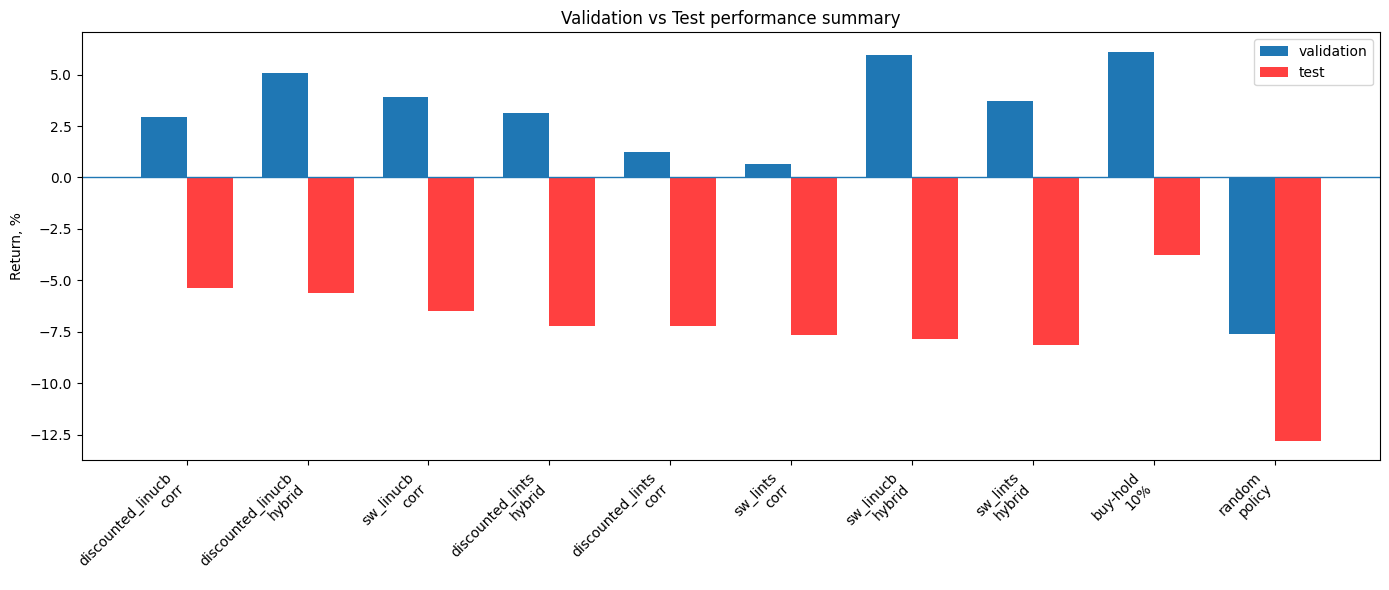

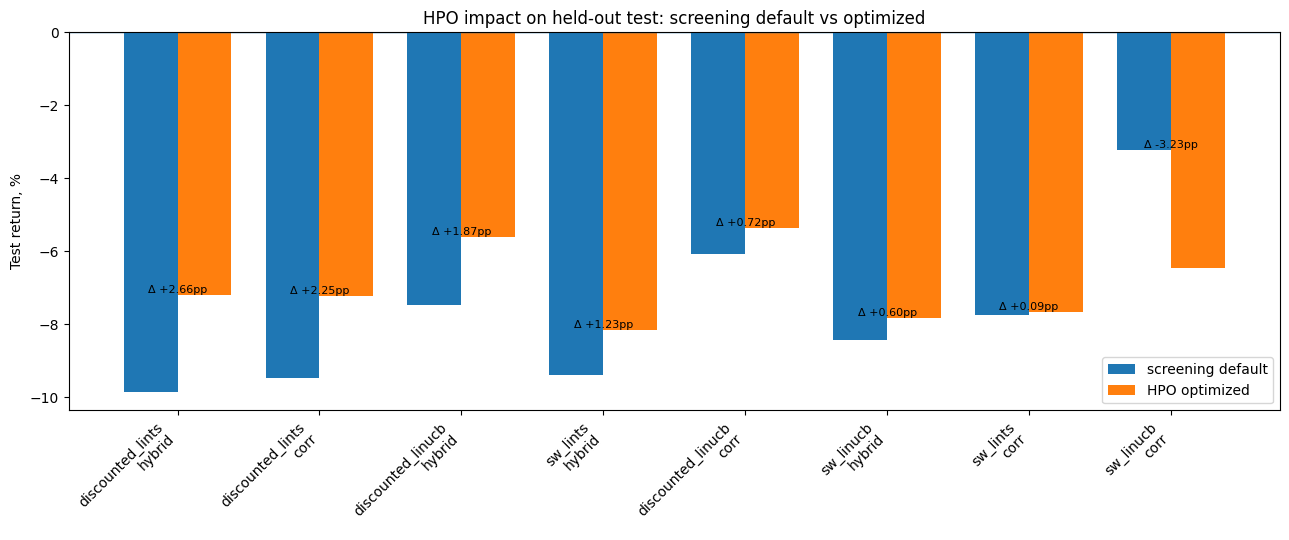

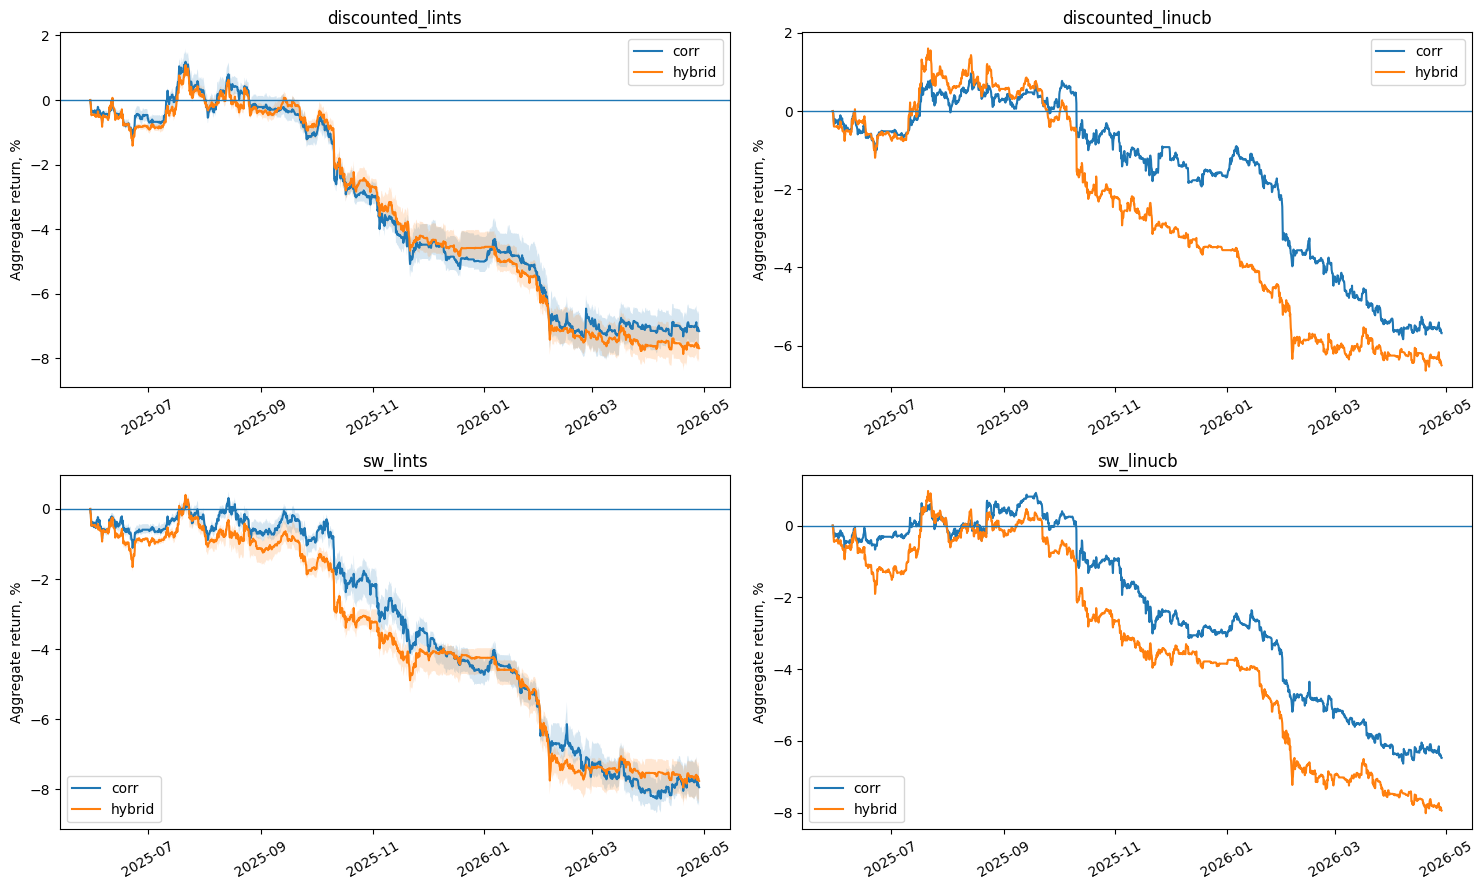

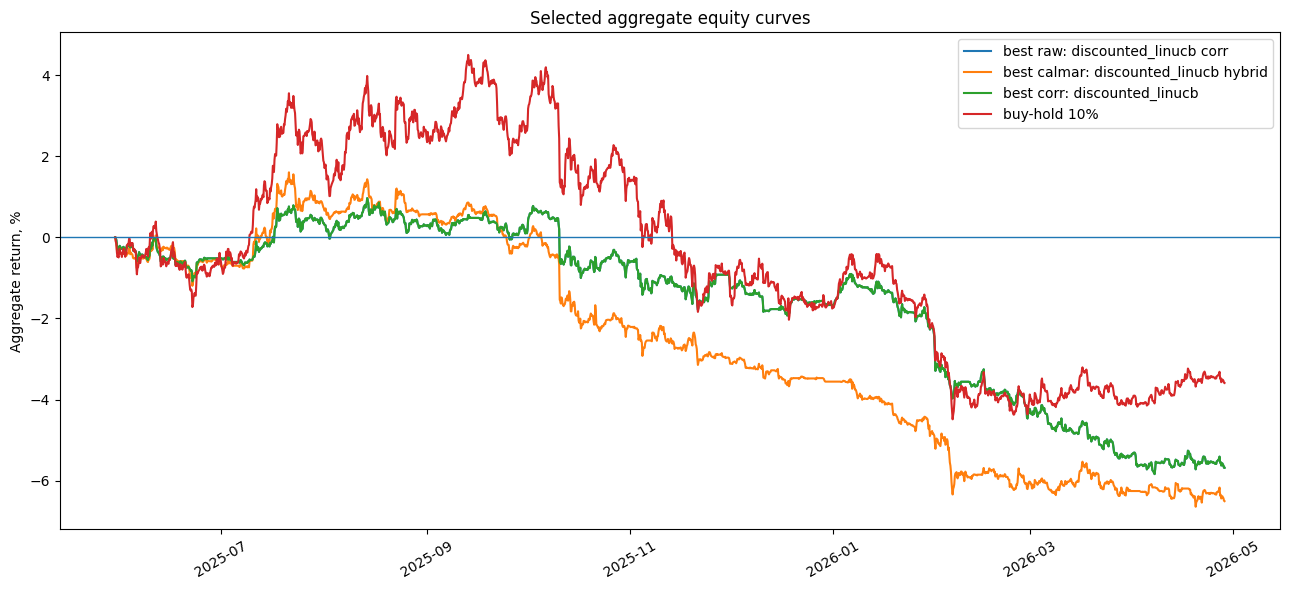

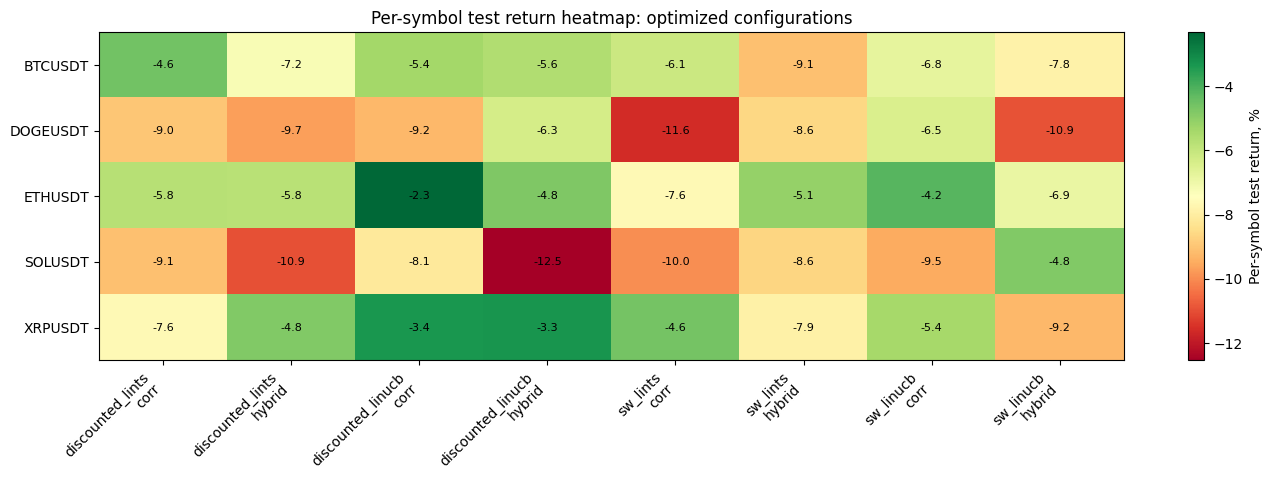

C:\Users\trosh\AppData\Local\Temp\ipykernel_14916\3542551187.py:174: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


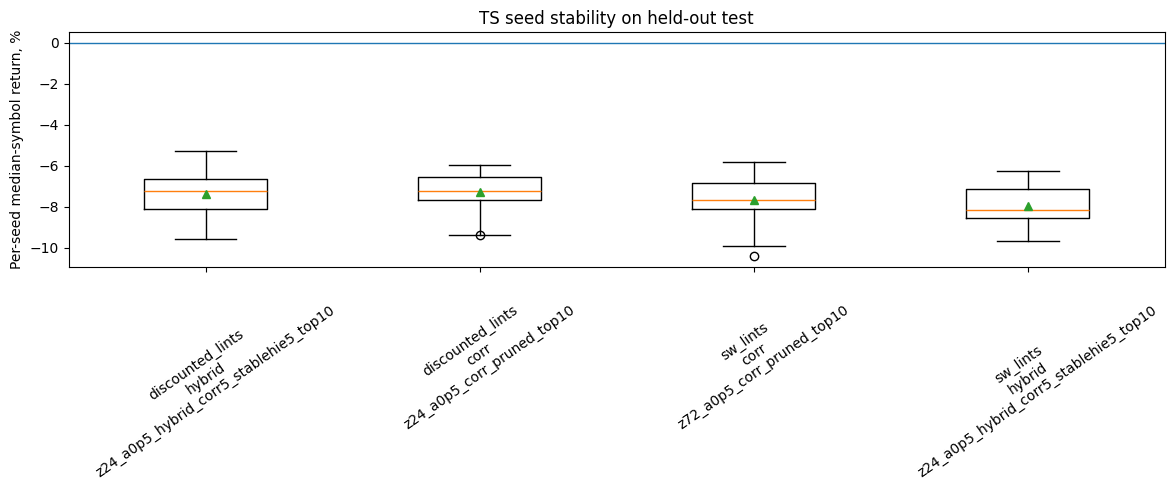

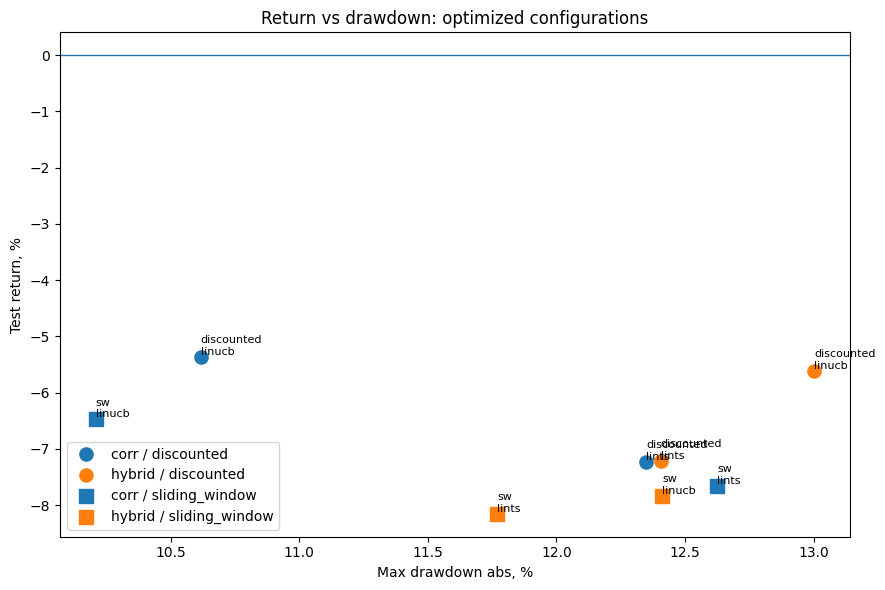

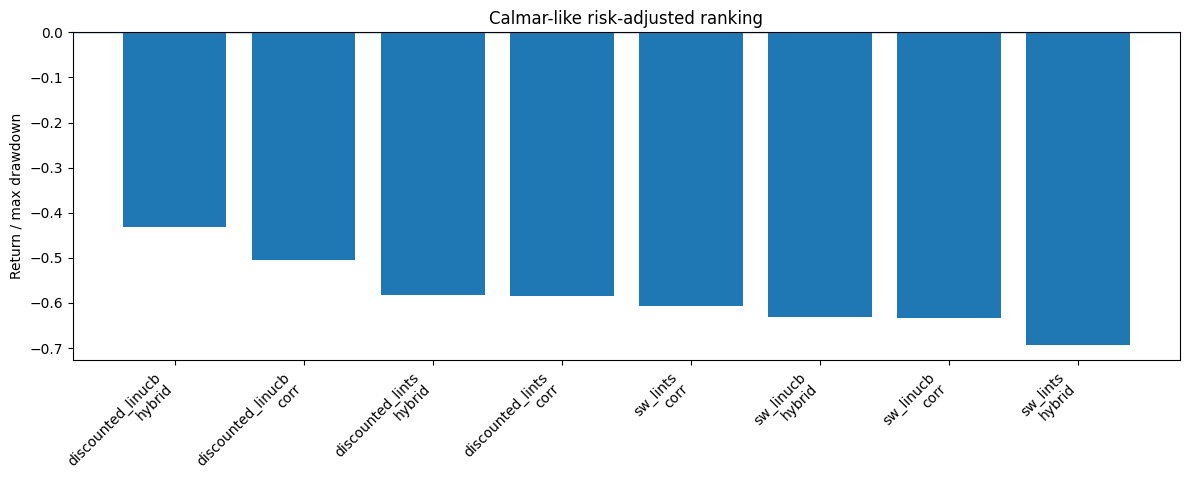

In [11]:
def savefig(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()


def get_curve_summary(config_id: str) -> pd.DataFrame:
    part = TEST_EQUITY_CURVES_AGG[TEST_EQUITY_CURVES_AGG["config_id"].eq(config_id)].copy()
    if part.empty:
        return pd.DataFrame()
    return (
        part.groupby("timestamp", as_index=False)
        .agg(
            median_return=("aggregate_return_pct", "median"),
            q25_return=("aggregate_return_pct", lambda x: x.quantile(0.25)),
            q75_return=("aggregate_return_pct", lambda x: x.quantile(0.75)),
            mean_return=("aggregate_return_pct", "mean"),
            n_seeds=("seed", "nunique"),
        )
    )

# ---------------------------------------------------------------------
# 1. Performance summary: validation vs test
# ---------------------------------------------------------------------
plot_items = []
for _, row in optimized_ranking.iterrows():
    plot_items.append({
        "label": f"{row['algorithm']}\n{row['method_group']}",
        "config_id": row["config_id"],
        "validation": row["validation_selected_return_pct"],
        "test": row["test_return_pct"],
    })
# Add buy-and-hold and random.
for bid, label in [
    ("baseline__buy_hold_entry_cost_position_size", "buy-hold\n10%"),
    ("baseline__random_policy", "random\npolicy"),
]:
    test_row = summary[summary["config_id"].eq(bid)]
    val_row = BASELINE_VAL_SUMMARY[BASELINE_VAL_SUMMARY["config_id"].eq(bid)] if not BASELINE_VAL_SUMMARY.empty else pd.DataFrame()
    if not test_row.empty:
        plot_items.append({
            "label": label,
            "config_id": bid,
            "validation": float(val_row["median_of_seed_median_return_pct"].iloc[0]) if not val_row.empty else np.nan,
            "test": float(test_row["test_return_pct"].iloc[0]),
        })
perf = pd.DataFrame(plot_items)

x = np.arange(len(perf))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, perf["validation"], width, label="validation")
colors = ["green" if (pd.notna(v) and t >= v) else "red" for v, t in zip(perf["validation"], perf["test"])]
ax.bar(x + width/2, perf["test"], width, label="test", color=colors, alpha=0.75)
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(perf["label"], rotation=45, ha="right")
ax.set_ylabel("Return, %")
ax.set_title("Validation vs Test performance summary")
ax.legend()
savefig(PLOTS_DIR / "performance_summary_validation_vs_test.png")


# ---------------------------------------------------------------------
# 1b. HPO impact: screening defaults vs optimized configs on TEST
# ---------------------------------------------------------------------
if not optimized_vs_default.empty:
    hpo_plot = optimized_vs_default.copy()
    hpo_plot["label"] = hpo_plot["algorithm"] + "\n" + hpo_plot["method_group"]
    hpo_plot = hpo_plot.sort_values("optimized_minus_default_return", ascending=False).reset_index(drop=True)

    x = np.arange(len(hpo_plot))
    width = 0.38
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.bar(x - width / 2, hpo_plot["default_test_return"], width, label="screening default")
    ax.bar(x + width / 2, hpo_plot["optimized_test_return"], width, label="HPO optimized")

    for i, row in hpo_plot.iterrows():
        diff = float(row["optimized_minus_default_return"])
        y = max(float(row["default_test_return"]), float(row["optimized_test_return"]))
        ax.text(i, y, f"Δ {diff:+.2f}pp", ha="center", va="bottom", fontsize=8)

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(hpo_plot["label"], rotation=45, ha="right")
    ax.set_ylabel("Test return, %")
    ax.set_title("HPO impact on held-out test: screening default vs optimized")
    ax.legend()
    savefig(PLOTS_DIR / "hpo_impact_default_vs_optimized.png")
else:
    print("Skipping HPO impact plot: optimized_vs_default is empty.")

# ---------------------------------------------------------------------
# 2. Hybrid vs Corr per algorithm (4 subplots)
# ---------------------------------------------------------------------
algos = ["discounted_lints", "discounted_linucb", "sw_lints", "sw_linucb"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
for ax, algo in zip(axes.ravel(), algos):
    part = optimized_ranking[optimized_ranking["algorithm"].eq(algo)]
    for method in ["corr", "hybrid"]:
        row = part[part["method_group"].eq(method)]
        if row.empty:
            continue
        cid = row.iloc[0]["config_id"]
        curve = get_curve_summary(cid)
        if curve.empty:
            continue
        ax.plot(curve["timestamp"], curve["median_return"], label=method)
        if int(curve["n_seeds"].max()) > 1:
            ax.fill_between(curve["timestamp"], curve["q25_return"], curve["q75_return"], alpha=0.18)
    ax.axhline(0, linewidth=1)
    ax.set_title(algo)
    ax.set_ylabel("Aggregate return, %")
    ax.legend()
for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=30)
savefig(PLOTS_DIR / "hybrid_vs_corr_equity_curves_4subplots.png")

# ---------------------------------------------------------------------
# 3. Selected equity curves: best raw, best risk-adjusted, best corr, buy-and-hold
# ---------------------------------------------------------------------
best_raw = optimized_ranking.sort_values("test_return_pct", ascending=False).iloc[0]
best_calmar = optimized_ranking.sort_values("test_calmar_like", ascending=False).iloc[0]
best_corr = optimized_ranking[optimized_ranking["method_group"].eq("corr")].sort_values("test_return_pct", ascending=False).iloc[0]
selected_curve_items = [
    (best_raw["config_id"], f"best raw: {best_raw['algorithm']} {best_raw['method_group']}"),
    (best_calmar["config_id"], f"best calmar: {best_calmar['algorithm']} {best_calmar['method_group']}"),
    (best_corr["config_id"], f"best corr: {best_corr['algorithm']}"),
    ("baseline__buy_hold_entry_cost_position_size", "buy-hold 10%"),
]
fig, ax = plt.subplots(figsize=(13, 6))
for cid, label in selected_curve_items:
    curve = get_curve_summary(cid)
    if curve.empty:
        continue
    ax.plot(curve["timestamp"], curve["median_return"], label=label)
    if int(curve["n_seeds"].max()) > 1:
        ax.fill_between(curve["timestamp"], curve["q25_return"], curve["q75_return"], alpha=0.14)
ax.axhline(0, linewidth=1)
ax.set_title("Selected aggregate equity curves")
ax.set_ylabel("Aggregate return, %")
ax.legend()
ax.tick_params(axis="x", rotation=30)
savefig(PLOTS_DIR / "selected_equity_curves.png")

# ---------------------------------------------------------------------
# 4. Per-symbol heatmap for optimized configs
# ---------------------------------------------------------------------
heat = per_symbol_optimized.copy()
heat["col"] = heat["algorithm"] + "\n" + heat["method_group"]
heat_pivot = heat.pivot_table(index="symbol", columns="col", values="median_return_pct", aggfunc="first").reindex(ALL_SYMBOLS)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat_pivot.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn")
ax.set_xticks(np.arange(heat_pivot.shape[1]))
ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(heat_pivot.shape[0]))
ax.set_yticklabels(heat_pivot.index)
for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Per-symbol test return, %")
ax.set_title("Per-symbol test return heatmap: optimized configurations")
savefig(PLOTS_DIR / "per_symbol_return_heatmap.png")

# ---------------------------------------------------------------------
# 5. TS seed variance boxplots
# ---------------------------------------------------------------------
ts_seed = TEST_SEED_SUMMARY[(TEST_SEED_SUMMARY["config_type"].eq("optimized")) & (TEST_SEED_SUMMARY["exploration_family"].eq("TS"))].copy()
ts_order = ts_seed.groupby("config_id")["median_return_pct"].median().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
data = [ts_seed[ts_seed["config_id"].eq(cid)]["median_return_pct"].to_numpy() for cid in ts_order]
labels = [cid.replace("optimized__", "").replace("__", "\n") for cid in ts_order]
ax.boxplot(data, labels=labels, showmeans=True)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Per-seed median-symbol return, %")
ax.set_title("TS seed stability on held-out test")
ax.tick_params(axis="x", rotation=35)
savefig(PLOTS_DIR / "ts_seed_variance_boxplots.png")

# ---------------------------------------------------------------------
# 6. Return vs Drawdown scatter
# ---------------------------------------------------------------------
plot_scatter = optimized_ranking.copy()
marker_map = {"discounted": "o", "sliding_window": "s"}
color_map = {"corr": "tab:blue", "hybrid": "tab:orange"}
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in plot_scatter.iterrows():
    ax.scatter(
        row["median_max_drawdown_abs"],
        row["test_return_pct"],
        marker=marker_map.get(row["algorithm_family"], "o"),
        color=color_map.get(row["method_group"], "gray"),
        s=90,
        label=f"{row['method_group']} / {row['algorithm_family']}",
    )
    ax.text(row["median_max_drawdown_abs"], row["test_return_pct"], row["algorithm"].replace("_", "\n"), fontsize=8, ha="left", va="bottom")
# deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.axhline(0, linewidth=1)
ax.set_xlabel("Max drawdown abs, %")
ax.set_ylabel("Test return, %")
ax.set_title("Return vs drawdown: optimized configurations")
savefig(PLOTS_DIR / "return_vs_drawdown_scatter.png")

# ---------------------------------------------------------------------
# 7. Calmar-like ranking
# ---------------------------------------------------------------------
calmar_plot = optimized_ranking.sort_values("test_calmar_like", ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{a}\n{m}" for a, m in zip(calmar_plot["algorithm"], calmar_plot["method_group"])]
ax.bar(np.arange(len(calmar_plot)), calmar_plot["test_calmar_like"])
ax.axhline(0, linewidth=1)
ax.set_xticks(np.arange(len(calmar_plot)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Return / max drawdown")
ax.set_title("Calmar-like risk-adjusted ranking")
savefig(PLOTS_DIR / "calmar_like_ranking.png")

## 11. Output checklist

In [12]:
expected_outputs = [
    OUTPUT_DIR / "final_test_configurations.csv",
    OUTPUT_DIR / "test_seed_level_summary_all.csv",
    OUTPUT_DIR / "test_config_summary_all.csv",
    OUTPUT_DIR / "test_final_ranking_all.csv",
    OUTPUT_DIR / "test_optimized_config_ranking.csv",
    OUTPUT_DIR / "test_corr_vs_hybrid_by_algorithm.csv",
    OUTPUT_DIR / "test_optimized_vs_default.csv",
    OUTPUT_DIR / "test_per_symbol_metrics_optimized.csv",
    OUTPUT_DIR / "test_ts_seed_stability.csv",
    DIAGNOSTICS_DIR / "test_symbol_metrics_all.csv",
    DIAGNOSTICS_DIR / "test_aggregate_equity_curves.csv",
    DIAGNOSTICS_DIR / "test_split_summary_used.csv",
    PLOTS_DIR / "performance_summary_validation_vs_test.png",
    PLOTS_DIR / "hpo_impact_default_vs_optimized.png",
    PLOTS_DIR / "hybrid_vs_corr_equity_curves_4subplots.png",
    PLOTS_DIR / "selected_equity_curves.png",
    PLOTS_DIR / "per_symbol_return_heatmap.png",
    PLOTS_DIR / "ts_seed_variance_boxplots.png",
    PLOTS_DIR / "return_vs_drawdown_scatter.png",
    PLOTS_DIR / "calmar_like_ranking.png",
]

# Compatibility filenames expected by earlier notebooks.
TEST_SYMBOL_METRICS.to_csv(DIAGNOSTICS_DIR / "test_symbol_metrics_all.csv", index=False)
TEST_SEED_SUMMARY.to_csv(OUTPUT_DIR / "test_seed_level_summary_all.csv", index=False)
summary.to_csv(OUTPUT_DIR / "test_config_summary_all.csv", index=False)

for p in expected_outputs:
    print(p.name, "OK" if p.exists() else "MISSING", p)
print("OUTPUT_DIR:", OUTPUT_DIR)

final_test_configurations.csv OK D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\final_test_evaluation_outputs\final_test_fixed_optuna_30TS_1UCB_20260517_013520\final_test_configurations.csv
test_seed_level_summary_all.csv OK D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\final_test_evaluation_outputs\final_test_fixed_optuna_30TS_1UCB_20260517_013520\test_seed_level_summary_all.csv
test_config_summary_all.csv OK D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\final_test_evaluation_outputs\final_test_fixed_optuna_30TS_1UCB_20260517_013520\test_config_summary_all.csv
test_final_ranking_all.csv OK D:\PythonProjects\VKR\feature_selection\hybrid_stable_hie_corr_outputs_alpha0p5_train_only_v2\final_test_evaluation_outputs\final_test_fixed_optuna_30TS_1UCB_20260517_013520\test_final_ranking_all.csv
test_optimized_config_ranking.csv OK D:\PythonProjects\VKR